In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../Datasets/MachineLearningCVE/'

print("Loading Monday file...")
monday = pd.read_csv(DATA_PATH + 'Monday-WorkingHours.pcap_ISCX.csv', low_memory=False)
monday.columns = monday.columns.str.strip()

print(f"✅ Shape: {monday.shape}")
print(f"✅ Label values: {monday['Label'].unique()}")
print(f"✅ First 5 columns: {list(monday.columns[:5])}")
print(f"✅ Memory: {monday.memory_usage(deep=True).sum() / 1e6:.1f} MB")


ModuleNotFoundError: No module named 'pandas'

In [1]:
import sys
print(sys.executable)



/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/bin/python


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn joblib scipy tqdm


100.10s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 24.1 MB/s  0:00:00 25.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 17.4 MB/s  0:00:00 14.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 21.8 MB/s  0:00:007.3 MB/s eta 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 21.4 MB/s  0:00:00 23.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 20.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 15.3 MB/s  0:00:01 eta 0:00:010:01:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost

print(f"✅ pandas: {pd.__version__}")
print(f"✅ numpy: {np.__version__}")
print(f"✅ sklearn: {sklearn.__version__}")
print(f"✅ xgboost: {xgboost.__version__}")
print("\n🎉 All packages working! Ready to load data.")


✅ pandas: 2.3.3
✅ numpy: 2.2.6
✅ sklearn: 1.7.2
✅ xgboost: 3.2.0

🎉 All packages working! Ready to load data.


In [4]:
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../Datasets/MachineLearningCVE/'

print("Loading Monday file...")
monday = pd.read_csv(DATA_PATH + 'Monday-WorkingHours.pcap_ISCX.csv', low_memory=False)
monday.columns = monday.columns.str.strip()

print(f"✅ Shape: {monday.shape}")
print(f"✅ Labels: {monday['Label'].unique()}")
print(f"✅ Columns (first 5): {list(monday.columns[:5])}")


Loading Monday file...
✅ Shape: (529918, 79)
✅ Labels: ['BENIGN']
✅ Columns (first 5): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets']


In [5]:
import os

files = {
    'Monday':        'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday':       'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday':     'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday_Web':  'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday_Inf':  'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday_Morn':   'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday_DDoS':   'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday_Port':   'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
}

dfs = []
for day, filename in files.items():
    filepath = DATA_PATH + filename
    print(f"Loading {day}...", end=' ')
    df_temp = pd.read_csv(filepath, low_memory=False)
    df_temp.columns = df_temp.columns.str.strip()
    df_temp['day'] = day
    dfs.append(df_temp)
    print(f"✅ {df_temp.shape[0]:,} rows")

df = pd.concat(dfs, ignore_index=True)
print(f"\n🎉 Full dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")



Loading Monday... ✅ 529,918 rows
Loading Tuesday... ✅ 445,909 rows
Loading Wednesday... ✅ 692,703 rows
Loading Thursday_Web... ✅ 170,366 rows
Loading Thursday_Inf... ✅ 288,602 rows
Loading Friday_Morn... ✅ 191,033 rows
Loading Friday_DDoS... ✅ 225,745 rows
Loading Friday_Port... ✅ 286,467 rows

🎉 Full dataset: 2,830,743 rows × 80 columns
Memory: 2.13 GB


ATTACK TYPE DISTRIBUTION
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

Total unique labels: 15


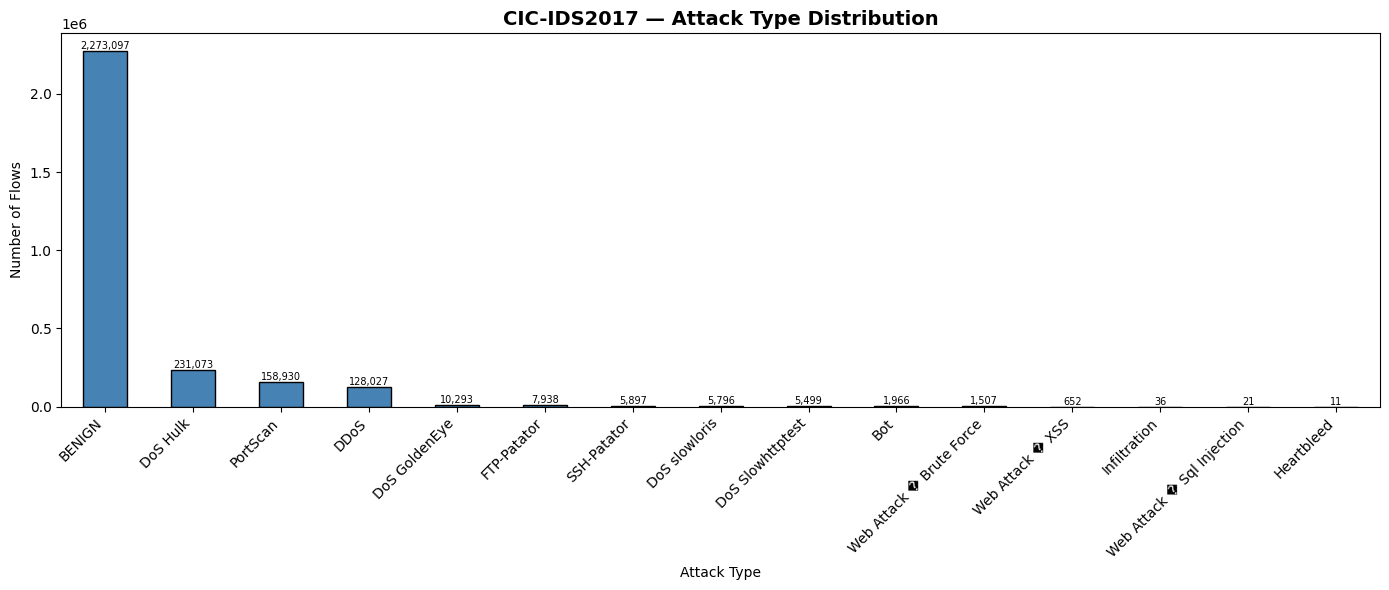

In [6]:
print("="*55)
print("ATTACK TYPE DISTRIBUTION")
print("="*55)
print(df['Label'].value_counts().to_string())
print(f"\nTotal unique labels: {df['Label'].nunique()}")

# Visualize
plt.figure(figsize=(14, 6))
ax = df['Label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('CIC-IDS2017 — Attack Type Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Number of Flows')
plt.xticks(rotation=45, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig('../results/01_attack_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
print("="*55)
print("DATA QUALITY REPORT")
print("="*55)

# Missing values
missing = df.isnull().sum()
print(f"Columns with missing values: {(missing > 0).sum()}")
print(missing[missing > 0])

# Infinite values
numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_count = np.isinf(df[numeric_cols]).sum().sum()
print(f"\nInfinite values: {inf_count:,}")

# Duplicates
dup_count = df.duplicated().sum()
print(f"Duplicate rows: {dup_count:,}")

# Class balance
normal = (df['Label'] == 'BENIGN').sum()
attack = (df['Label'] != 'BENIGN').sum()
total = len(df)
print(f"\nNormal (BENIGN): {normal:,} ({normal/total*100:.1f}%)")
print(f"Attack traffic:  {attack:,} ({attack/total*100:.1f}%)")
print(f"Imbalance ratio: {normal/attack:.1f}:1")


DATA QUALITY REPORT
Columns with missing values: 1
Flow Bytes/s    1358
dtype: int64

Infinite values: 4,376
Duplicate rows: 256,479

Normal (BENIGN): 2,273,097 (80.3%)
Attack traffic:  557,646 (19.7%)
Imbalance ratio: 4.1:1


In [8]:
# Fix infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Binary label (BENIGN=0, Attack=1)
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)

print(f"✅ Infinite values fixed")
print(f"✅ NaN values filled")
print(f"✅ Binary label added")
print(f"\nBinary label distribution:")
print(df['binary_label'].value_counts())
print(f"\nDataset ready for modelling!")



✅ Infinite values fixed
✅ NaN values filled
✅ Binary label added

Binary label distribution:
binary_label
0    2273097
1     557646
Name: count, dtype: int64

Dataset ready for modelling!


In [9]:
print("Saving processed datasets...")

df.to_pickle('../results/full_dataset.pkl')
print(f"✅ Full dataset saved: {df.shape}")

from sklearn.utils import resample

df_sample = df.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), int(500000 * len(x)/len(df))), random_state=42)
)
df_sample.to_pickle('../results/sample_dataset.pkl')
print(f"✅ Sample dataset saved: {df_sample.shape}")
print(f"\nSample distribution:")
print(df_sample['Label'].value_counts())


Saving processed datasets...
✅ Full dataset saved: (2830743, 81)
✅ Sample dataset saved: (499993, 81)

Sample distribution:
Label
BENIGN                        401501
DoS Hulk                       40814
PortScan                       28072
DDoS                           22613
DoS GoldenEye                   1818
FTP-Patator                     1402
SSH-Patator                     1041
DoS slowloris                   1023
DoS Slowhttptest                 971
Bot                              347
Web Attack � Brute Force         266
Web Attack � XSS                 115
Infiltration                       6
Web Attack � Sql Injection         3
Heartbleed                         1
Name: count, dtype: int64


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import time
import joblib

drop_cols = ['Label', 'binary_label', 'day']
X = df_sample.drop(drop_cols, axis=1)
y = df_sample['binary_label']

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]:,}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")

print("\n🚀 Training Random Forest (this takes 3-5 min)...")
start = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
y_pred = rf.predict(X_test)
inference_time = (time.time() - start) / len(X_test) * 1000

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n{'='*50}")
print(f"RANDOM FOREST RESULTS")
print(f"{'='*50}")
print(f"Accuracy:       {acc*100:.2f}%")
print(f"F1-Score:       {f1:.4f}")
print(f"Train time:     {train_time:.1f}s")
print(f"Inference:      {inference_time:.4f} ms/sample")
print(f"\n{classification_report(y_test, y_pred, target_names=['BENIGN','ATTACK'])}")

joblib.dump(rf, '../models/rf_baseline.pkl')
print("✅ Model saved!")


Features: 78
Samples: 499,993
Train: 399,994 | Test: 99,999

🚀 Training Random Forest (this takes 3-5 min)...

RANDOM FOREST RESULTS
Accuracy:       99.87%
F1-Score:       0.9987
Train time:     14.2s
Inference:      0.0021 ms/sample

              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     80301
      ATTACK       1.00      1.00      1.00     19698

    accuracy                           1.00     99999
   macro avg       1.00      1.00      1.00     99999
weighted avg       1.00      1.00      1.00     99999

✅ Model saved!


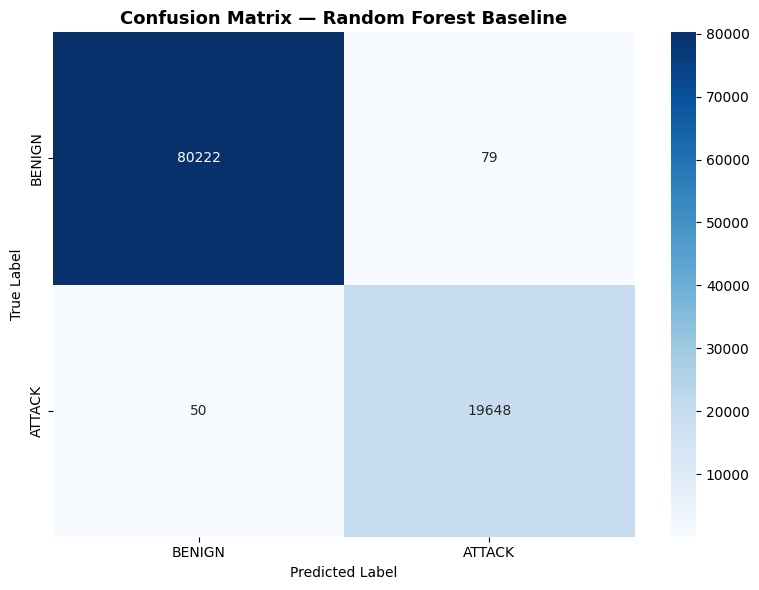

Detection Rate (TPR): 99.75%
False Positive Rate:  0.10%
Target FPR <3%: ✅ Achieved!


In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN', 'ATTACK'],
            yticklabels=['BENIGN', 'ATTACK'])
plt.title('Confusion Matrix — Random Forest Baseline', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../results/02_confusion_matrix_rf.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
tpr = tp / (tp + fn)
print(f"Detection Rate (TPR): {tpr*100:.2f}%")
print(f"False Positive Rate:  {fpr*100:.2f}%")
print(f"Target FPR <3%: {'✅ Achieved!' if fpr < 0.03 else '⚠️ Needs tuning'}")


In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_multi = le.fit_transform(df_sample['Label'])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print("🚀 Training Multi-class RF...")
start = time.time()
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_multi.fit(X_train_m, y_train_m)
train_time = time.time() - start

y_pred_m = rf_multi.predict(X_test_m)
acc_m = accuracy_score(y_test_m, y_pred_m)

print(f"Multi-class Accuracy: {acc_m*100:.2f}%")
print(f"Train time: {train_time:.1f}s")
print(f"\n{classification_report(y_test_m, y_pred_m, target_names=le.classes_)}")

joblib.dump(rf_multi, '../models/rf_multiclass.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("✅ Saved!")


ValueError: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.

In [13]:
from sklearn.preprocessing import LabelEncoder

# Check class counts in sample
print("Class counts in sample:")
print(df_sample['Label'].value_counts())

# Remove classes with fewer than 10 samples
min_samples = 10
class_counts = df_sample['Label'].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index
df_multi = df_sample[df_sample['Label'].isin(valid_classes)].copy()

print(f"\nRemoved classes with <{min_samples} samples")
print(f"Remaining classes: {df_multi['Label'].nunique()}")
print(f"Remaining samples: {df_multi.shape[0]:,}")

# Encode labels
le = LabelEncoder()
y_multi = le.fit_transform(df_multi['Label'])

# Features
drop_cols = ['Label', 'binary_label', 'day']
X_multi = df_multi.drop(drop_cols, axis=1)

# Split
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

print(f"\nTrain: {X_train_m.shape[0]:,} | Test: {X_test_m.shape[0]:,}")

# Train
print("\n🚀 Training Multi-class RF...")
start = time.time()
rf_multi = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_multi.fit(X_train_m, y_train_m)
train_time = time.time() - start

y_pred_m = rf_multi.predict(X_test_m)
acc_m = accuracy_score(y_test_m, y_pred_m)

print(f"\n{'='*50}")
print(f"MULTI-CLASS RF RESULTS")
print(f"{'='*50}")
print(f"Accuracy:   {acc_m*100:.2f}%")
print(f"Train time: {train_time:.1f}s")
print(f"\n{classification_report(y_test_m, y_pred_m, target_names=le.classes_)}")

joblib.dump(rf_multi, '../models/rf_multiclass.pkl')
joblib.dump(le, '../models/label_encoder.pkl')
print("✅ Multi-class model saved!")



Class counts in sample:
Label
BENIGN                        401501
DoS Hulk                       40814
PortScan                       28072
DDoS                           22613
DoS GoldenEye                   1818
FTP-Patator                     1402
SSH-Patator                     1041
DoS slowloris                   1023
DoS Slowhttptest                 971
Bot                              347
Web Attack � Brute Force         266
Web Attack � XSS                 115
Infiltration                       6
Web Attack � Sql Injection         3
Heartbleed                         1
Name: count, dtype: int64

Removed classes with <10 samples
Remaining classes: 12
Remaining samples: 499,983

Train: 399,986 | Test: 99,997

🚀 Training Multi-class RF...

MULTI-CLASS RF RESULTS
Accuracy:   99.72%
Train time: 11.8s

                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00     80301
                     Bot       0.34      0.90     

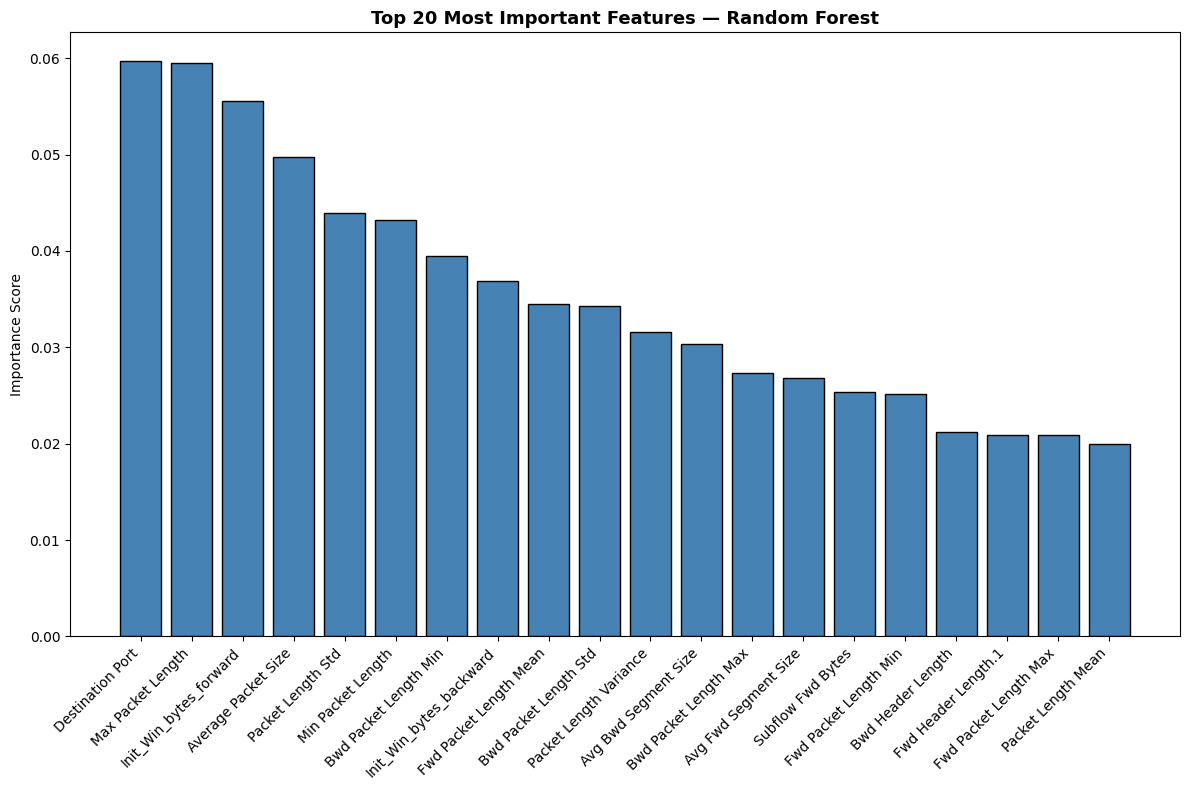

Top 10 features:
  1. Destination Port: 0.0597
  2. Max Packet Length: 0.0595
  3. Init_Win_bytes_forward: 0.0555
  4. Average Packet Size: 0.0498
  5. Packet Length Std: 0.0439
  6. Min Packet Length: 0.0432
  7. Bwd Packet Length Min: 0.0395
  8. Init_Win_bytes_backward: 0.0368
  9. Fwd Packet Length Mean: 0.0345
  10. Bwd Packet Length Std: 0.0342

MODEL SIZES
rf_baseline: 13.1 MB
rf_multiclass: 32.6 MB

Raspberry Pi 4 RAM: 8GB
Target model size: <50MB for edge deployment


In [14]:
# Feature Importance
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 8))
plt.bar(range(20), importances[indices], color='steelblue', edgecolor='black')
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Top 20 Most Important Features — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.savefig('../results/03_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 10 features:")
for i in range(10):
    print(f"  {i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

# Model sizes
import os
models = {
    'rf_baseline': '../models/rf_baseline.pkl',
    'rf_multiclass': '../models/rf_multiclass.pkl'
}
print(f"\n{'='*40}")
print("MODEL SIZES")
print(f"{'='*40}")
for name, path in models.items():
    size = os.path.getsize(path) / 1e6
    print(f"{name}: {size:.1f} MB")
    
print(f"\nRaspberry Pi 4 RAM: 8GB")
print(f"Target model size: <50MB for edge deployment")


In [15]:
# Still in Jupyter — run this now
top20_features = [feature_names[i] for i in indices[:20]]
X_reduced = X[top20_features]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42, stratify=y
)

print("🚀 Training Reduced RF (top 20 features)...")
start = time.time()
rf_reduced = RandomForestClassifier(n_estimators=100, max_depth=20,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_reduced.fit(X_train_r, y_train_r)

y_pred_r = rf_reduced.predict(X_test_r)
inf_time = (time.time() - start) / len(X_test_r) * 1000
acc_r = accuracy_score(y_test_r, y_pred_r)
tn,fp,fn,tp = confusion_matrix(y_test_r, y_pred_r).ravel()

joblib.dump(rf_reduced, '../models/rf_reduced_top20.pkl')
size_r = os.path.getsize('../models/rf_reduced_top20.pkl') / 1e6

print(f"Accuracy:   {acc_r*100:.2f}%")
print(f"FPR:        {fp/(fp+tn)*100:.2f}%")
print(f"Model size: {size_r:.1f} MB")
print(f"Inference:  {inf_time:.4f} ms/sample")


🚀 Training Reduced RF (top 20 features)...
Accuracy:   99.68%
FPR:        0.36%
Model size: 7.4 MB
Inference:  0.0651 ms/sample


In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Check class distribution first
print(df['Label'].value_counts())


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [17]:
# Merge very rare classes into an "Other" group to avoid SMOTE issues
rare_classes = ['Infiltration', 'Web Attack  Sql Injection', 'Heartbleed']
df['Label'] = df['Label'].apply(lambda x: 'Other Attack' if x in rare_classes else x)
print(df['Label'].value_counts())



Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Other Attack                       47
Web Attack � Sql Injection         21
Name: count, dtype: int64


In [18]:
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

X = df.drop('Label', axis=1)
y = df['Label']

# Split FIRST, then resample only training data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTETomek = SMOTE oversampling + Tomek undersampling (best combo for IDS)
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", y_train_res.value_counts())


ValueError: could not convert string to float: 'Wednesday'

In [19]:
# Check which columns have non-numeric data
print(df.dtypes[df.dtypes == 'object'])
print(df.shape)


Label    object
day      object
dtype: object
(2830743, 81)


In [20]:
import pandas as pd
import numpy as np

# Drop non-numeric columns except Label
non_numeric = df.select_dtypes(include=['object']).columns.tolist()
print("Non-numeric columns:", non_numeric)

# Remove 'Label' from this list (we need it separately)
cols_to_drop = [col for col in non_numeric if col != ' Label' and col != 'Label']
df_clean = df.drop(columns=cols_to_drop)

print("Remaining non-numeric:", df_clean.select_dtypes(include=['object']).columns.tolist())


Non-numeric columns: ['Label', 'day']
Remaining non-numeric: ['Label']


In [21]:
# CICIDS2017 is known to have inf values — replace them
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

print(f"Dataset shape after cleaning: {df_clean.shape}")


Dataset shape after cleaning: (2830743, 80)


In [22]:
from sklearn.model_selection import train_test_split

# Fix label column name — CICIDS2017 has a space: ' Label'
label_col = ' Label' if ' Label' in df_clean.columns else 'Label'

X = df_clean.drop(columns=[label_col])
y = df_clean[label_col].str.strip()  # Remove whitespace from labels

print("X shape:", X.shape)
print("y unique values:", y.unique())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


X shape: (2830743, 79)
y unique values: ['BENIGN' 'FTP-Patator' 'SSH-Patator' 'DoS slowloris' 'DoS Slowhttptest'
 'DoS Hulk' 'DoS GoldenEye' 'Other Attack' 'Web Attack � Brute Force'
 'Web Attack � XSS' 'Web Attack � Sql Injection' 'Bot' 'DDoS' 'PortScan']


In [ ]:
 import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Drop 'day' column + handle inf/NaN
df_clean = df.drop(columns=['day'])
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

print(f"Shape after cleaning: {df_clean.shape}")

# Fix label column (CICIDS2017 sometimes has leading space)
label_col = ' Label' if ' Label' in df_clean.columns else 'Label'

X = df_clean.drop(columns=[label_col])
y = df_clean[label_col].str.strip()  # removes any whitespace

print("Feature shape:", X.shape)
print("\nClass distribution:\n", y.value_counts())


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Drop 'day' column + handle inf/NaN
df_clean = df.drop(columns=['day'])
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna()

print(f"Shape after cleaning: {df_clean.shape}")

# Fix label column (CICIDS2017 sometimes has leading space)
label_col = ' Label' if ' Label' in df_clean.columns else 'Label'

X = df_clean.drop(columns=[label_col])
y = df_clean[label_col].str.strip()  # removes any whitespace

print("Feature shape:", X.shape)
print("\nClass distribution:\n", y.value_counts())


NameError: name 'df' is not defined

In [2]:
import pandas as pd
import numpy as np
import glob
import os

# Load all CSV files from both dataset folders
folder1 = "Datasets/MachineLearningCVE/"
folder2 = "Datasets/TrafficLabelling /"  # Note the space in folder name

files1 = glob.glob(folder1 + "*.csv")
files2 = glob.glob(folder2 + "*.csv")
all_files = files1 + files2

print(f"Found {len(all_files)} CSV files:")
for f in all_files:
    print(f"  {f}")


Found 0 CSV files:


In [3]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# List everything in current directory
print("\nContents:")
for item in os.listdir('.'):
    print(f"  {item}")



Current directory: /Users/malharfalke/College/Btech_Project /code

Contents:
  01_Dataset_EDA .ipynb
  .ipynb_checkpoints


In [4]:
import os

# Check current working directory
print("Current directory:", os.getcwd())

# List everything in current directory
print("\nContents:")
for item in os.listdir('.'):
    print(f"  {item}")


Current directory: /Users/malharfalke/College/Btech_Project /code

Contents:
  01_Dataset_EDA .ipynb
  .ipynb_checkpoints


In [5]:
import os

# Go one level up and check
parent = '/Users/malharfalke/College/Btech_Project '
print("Contents of Btech_Project:")
for item in os.listdir(parent):
    print(f"  {item}")


Contents of Btech_Project:
  .DS_Store
  Literature
  code
  models
  README.md
  results
  .gitignore
  .git


In [6]:
import subprocess

result = subprocess.run(
    ['find', '/Users/malharfalke', '-name', '*.pcap_ISCX.csv', '-type', 'f'],
    capture_output=True, text=True, timeout=60
)
print(result.stdout if result.stdout else "No files found")
print(result.stderr if result.stderr else "")



No files found
find: /Users/malharfalke/Library/Application Support/MobileSync: Operation not permitted
find: /Users/malharfalke/Library/Application Support/CallHistoryTransactions: Operation not permitted
find: /Users/malharfalke/Library/Application Support/CloudDocs: Operation not permitted
find: /Users/malharfalke/Library/Application Support/com.apple.sharedfilelist: Operation not permitted
find: /Users/malharfalke/Library/Application Support/Knowledge: Operation not permitted
find: /Users/malharfalke/Library/Application Support/com.apple.TCC: Operation not permitted
find: /Users/malharfalke/Library/Application Support/FileProvider: Operation not permitted
find: /Users/malharfalke/Library/Application Support/AddressBook: Operation not permitted
find: /Users/malharfalke/Library/Application Support/FaceTime: Operation not permitted
find: /Users/malharfalke/Library/Application Support/DifferentialPrivacy: Operation not permitted
find: /Users/malharfalke/Library/Application Support/com.

In [7]:
import os
import glob
import pandas as pd
import numpy as np

# Set path
DATA_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/MachineLearningCVE/'

# Check files
files = glob.glob(DATA_PATH + '*.csv')
print(f"Found {len(files)} CSV files:")
for f in files:
    size = os.path.getsize(f) / (1024*1024)
    print(f"  {os.path.basename(f)} — {size:.1f} MB")


Found 0 CSV files:


In [8]:
import os
import glob
import pandas as pd
import numpy as np

# Set path
DATA_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/MachineLearningCVE/'

# Check files
files = glob.glob(DATA_PATH + '*.csv')
print(f"Found {len(files)} CSV files:")
for f in files:
    size = os.path.getsize(f) / (1024*1024)
    print(f"  {os.path.basename(f)} — {size:.1f} MB")



Found 8 CSV files:
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — 79.3 MB
  Monday-WorkingHours.pcap_ISCX.csv — 168.7 MB
  Friday-WorkingHours-Morning.pcap_ISCX.csv — 55.6 MB
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — 73.3 MB
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — 73.6 MB
  Tuesday-WorkingHours.pcap_ISCX.csv — 128.8 MB
  Wednesday-workingHours.pcap_ISCX.csv — 214.7 MB
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — 49.6 MB


In [9]:
# Load all CSVs
dfs = []
for f in files:
    try:
        temp = pd.read_csv(f, low_memory=False)
        temp.columns = temp.columns.str.strip()  # Remove whitespace from column names
        print(f"✅ {os.path.basename(f)} — {temp.shape}")
        dfs.append(temp)
    except Exception as e:
        print(f"❌ Failed: {os.path.basename(f)} — {e}")

# Combine all files
df = pd.concat(dfs, ignore_index=True)
print(f"\nFull dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['Label'].value_counts()}")



✅ Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv — (288602, 79)
✅ Monday-WorkingHours.pcap_ISCX.csv — (529918, 79)
✅ Friday-WorkingHours-Morning.pcap_ISCX.csv — (191033, 79)
✅ Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv — (286467, 79)
✅ Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv — (225745, 79)
✅ Tuesday-WorkingHours.pcap_ISCX.csv — (445909, 79)
✅ Wednesday-workingHours.pcap_ISCX.csv — (692703, 79)
✅ Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv — (170366, 79)

Full dataset shape: (2830743, 79)

Class distribution:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS   

In [10]:
# ── Step 1: Clean ──────────────────────────────────────────
# Fix encoding issues in label names
df['Label'] = df['Label'].str.strip()
df['Label'] = df['Label'].replace({
    'Web Attack \x96 Brute Force': 'Web Attack Brute Force',
    'Web Attack \x96 XSS':         'Web Attack XSS',
    'Web Attack \x96 Sql Injection':'Web Attack Sql Injection'
})

# Drop inf and NaN (common in Flow Bytes/s column)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()
print(f"Shape after cleaning: {df.shape}")

# ── Step 2: Group rare classes ─────────────────────────────
rare = ['Infiltration', 'Web Attack Sql Injection', 'Heartbleed']
df['Label'] = df['Label'].apply(lambda x: 'Other Attack' if x in rare else x)
print(f"\nFinal class distribution:\n{df['Label'].value_counts()}")

# ── Step 3: Split features and labels ─────────────────────
X = df.drop(columns=['Label'])
y = df['Label']

print(f"\nFeature shape: {X.shape}")
print(f"Label shape:   {y.shape}")


Shape after cleaning: (2827876, 79)

Final class distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Other Attack                       47
Web Attack � Sql Injection         21
Name: count, dtype: int64

Feature shape: (2827876, 78)
Label shape:   (2827876,)


In [11]:
# ── Fix encoding with a catch-all approach ─────────────────
df['Label'] = df['Label'].apply(lambda x: 
    'Web Attack Brute Force' if 'Brute' in str(x) else
    'Web Attack XSS'         if 'XSS'   in str(x) else
    'Web Attack Sql'         if 'Sql'   in str(x) else x
)

# Group rare classes again
rare = ['Infiltration', 'Web Attack Sql', 'Heartbleed', 'Other Attack']
df['Label'] = df['Label'].apply(lambda x: 'Other Attack' if x in rare else x)

print("Final class distribution:")
print(df['Label'].value_counts())
print(f"\nTotal classes: {df['Label'].nunique()}")


Final class distribution:
Label
BENIGN                    2271320
DoS Hulk                   230124
PortScan                   158804
DDoS                       128025
DoS GoldenEye               10293
FTP-Patator                  7935
SSH-Patator                  5897
DoS slowloris                5796
DoS Slowhttptest             5499
Bot                          1956
Web Attack Brute Force       1507
Web Attack XSS                652
Other Attack                   68
Name: count, dtype: int64

Total classes: 13


In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Label'])
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")



Train: (2262300, 78)
Test:  (565576, 78)

Train class distribution:
Label
BENIGN                    1817055
DoS Hulk                   184099
PortScan                   127043
DDoS                       102420
DoS GoldenEye                8234
FTP-Patator                  6348
SSH-Patator                  4718
DoS slowloris                4637
DoS Slowhttptest             4399
Bot                          1565
Web Attack Brute Force       1206
Web Attack XSS                522
Other Attack                   54
Name: count, dtype: int64


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

# ── Step 1: Scale ──────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("✅ Scaling done")

# ── Step 2: Train Random Forest ────────────────────────────
print("\nTraining Random Forest...")
start = time.time()

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,          # use all CPU cores
    max_depth=20,       # limit depth to speed up training
    min_samples_leaf=5
)
rf.fit(X_train_scaled, y_train)

elapsed = time.time() - start
print(f"✅ Training done in {elapsed/60:.1f} minutes")

# ── Step 3: Evaluate ───────────────────────────────────────
y_pred = rf.predict(X_test_scaled)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


✅ Scaling done

Training Random Forest...
✅ Training done in 1.5 minutes

Classification Report:
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    454265
                   Bot       0.20      0.99      0.33       391
                  DDoS       1.00      1.00      1.00     25605
         DoS GoldenEye       0.99      1.00      0.99      2059
              DoS Hulk       0.99      1.00      1.00     46025
      DoS Slowhttptest       0.99      0.99      0.99      1100
         DoS slowloris       1.00      1.00      1.00      1159
           FTP-Patator       1.00      1.00      1.00      1587
          Other Attack       1.00      0.57      0.73        14
              PortScan       0.99      1.00      1.00     31761
           SSH-Patator       1.00      1.00      1.00      1179
Web Attack Brute Force       0.79      0.67      0.73       301
        Web Attack XSS       0.39      0.60      0.47       130

     

In [14]:
import joblib
import os

# Create models folder if not exists
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Save model and scaler
joblib.dump(rf, '../models/random_forest_v1.pkl')
joblib.dump(scaler, '../models/scaler_v1.pkl')
print("✅ Model saved")

# Save classification report as CSV
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('../results/rf_classification_report.csv')
print("✅ Results saved")
print(report_df.round(3))


✅ Model saved
✅ Results saved
                        precision  recall  f1-score     support
BENIGN                      1.000   0.995     0.998  454265.000
Bot                         0.196   0.995     0.328     391.000
DDoS                        1.000   0.999     1.000   25605.000
DoS GoldenEye               0.993   0.995     0.994    2059.000
DoS Hulk                    0.993   1.000     0.996   46025.000
DoS Slowhttptest            0.992   0.992     0.992    1100.000
DoS slowloris               0.996   0.997     0.997    1159.000
FTP-Patator                 1.000   0.999     1.000    1587.000
Other Attack                1.000   0.571     0.727      14.000
PortScan                    0.995   1.000     0.997   31761.000
SSH-Patator                 1.000   0.999     1.000    1179.000
Web Attack Brute Force      0.792   0.671     0.727     301.000
Web Attack XSS              0.392   0.600     0.474     130.000
accuracy                    0.996   0.996     0.996       0.996
macro avg 

In [15]:
# Install if needed
# pip install xgboost

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost needs numeric labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

print("Classes:", list(le.classes_))

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

import time
start = time.time()
xgb.fit(X_train_scaled, y_train_enc)
print(f"✅ XGBoost trained in {(time.time()-start)/60:.1f} minutes")

y_pred_xgb = le.inverse_transform(xgb.predict(X_test_scaled))
print(classification_report(y_test, y_pred_xgb))


Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Other Attack', 'PortScan', 'SSH-Patator', 'Web Attack Brute Force', 'Web Attack XSS']


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [19:09:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost trained in 2.6 minutes
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    454265
                   Bot       0.96      0.73      0.83       391
                  DDoS       1.00      1.00      1.00     25605
         DoS GoldenEye       1.00      0.99      1.00      2059
              DoS Hulk       1.00      1.00      1.00     46025
      DoS Slowhttptest       0.99      0.99      0.99      1100
         DoS slowloris       1.00      1.00      1.00      1159
           FTP-Patator       1.00      1.00      1.00      1587
          Other Attack       1.00      0.57      0.73        14
              PortScan       0.99      1.00      1.00     31761
           SSH-Patator       1.00      1.00      1.00      1179
Web Attack Brute Force       0.71      0.91      0.79       301
        Web Attack XSS       0.38      0.15      0.22       130

              accuracy                           1.00    565576
     

In [16]:
import joblib, os
import pandas as pd
from sklearn.metrics import classification_report

os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

# Save models
joblib.dump(rf,     '../models/random_forest_v1.pkl')
joblib.dump(xgb,    '../models/xgboost_v1.pkl')
joblib.dump(scaler, '../models/scaler_v1.pkl')
joblib.dump(le,     '../models/label_encoder_v1.pkl')
print("✅ All models saved")

# Save reports
rf_report  = pd.DataFrame(classification_report(y_test, y_pred,     output_dict=True)).transpose()
xgb_report = pd.DataFrame(classification_report(y_test, y_pred_xgb, output_dict=True)).transpose()

rf_report.to_csv('../results/rf_report.csv')
xgb_report.to_csv('../results/xgb_report.csv')
print("✅ Reports saved")


✅ All models saved
✅ Reports saved


In [17]:
from imblearn.over_sampling import SMOTE

# Only oversample the weakest classes
smote = SMOTE(
    sampling_strategy={
        'Web Attack XSS':        2000,
        'Web Attack Brute Force': 3000,
        'Bot':                    3000,
        'Other Attack':           1000,
    },
    random_state=42,
    k_neighbors=3   # small k because some classes have very few samples
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print("After targeted SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After targeted SMOTE:
Label
BENIGN                    1817055
DoS Hulk                   184099
PortScan                   127043
DDoS                       102420
DoS GoldenEye                8234
FTP-Patator                  6348
SSH-Patator                  4718
DoS slowloris                4637
DoS Slowhttptest             4399
Bot                          3000
Web Attack Brute Force       3000
Web Attack XSS               2000
Other Attack                 1000
Name: count, dtype: int64


In [18]:
from xgboost import XGBClassifier
import time

# Encode new labels
y_train_sm_enc = le.transform(y_train_sm)

# Train XGBoost on SMOTE-balanced data
xgb_sm = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

start = time.time()
xgb_sm.fit(X_train_sm, y_train_sm_enc)
print(f"✅ Trained in {(time.time()-start)/60:.1f} minutes")

# Evaluate
y_pred_sm = le.inverse_transform(xgb_sm.predict(X_test_scaled))
print("\nClassification Report (XGBoost + SMOTE):")
print(classification_report(y_test, y_pred_sm))


✅ Trained in 1.4 minutes

Classification Report (XGBoost + SMOTE):
                        precision    recall  f1-score   support

                BENIGN       1.00      1.00      1.00    454265
                   Bot       0.77      0.88      0.82       391
                  DDoS       1.00      1.00      1.00     25605
         DoS GoldenEye       1.00      0.99      1.00      2059
              DoS Hulk       1.00      1.00      1.00     46025
      DoS Slowhttptest       0.99      0.99      0.99      1100
         DoS slowloris       1.00      1.00      1.00      1159
           FTP-Patator       1.00      1.00      1.00      1587
          Other Attack       0.90      0.64      0.75        14
              PortScan       0.99      1.00      1.00     31761
           SSH-Patator       1.00      1.00      1.00      1179
Web Attack Brute Force       0.77      0.73      0.75       301
        Web Attack XSS       0.44      0.52      0.47       130

              accuracy             

In [19]:
# Save best model
joblib.dump(xgb_sm, '../models/xgboost_smote_v1.pkl')
print("✅ Best model saved")

# Save final report
final_report = pd.DataFrame(
    classification_report(y_test, y_pred_sm, output_dict=True)
).transpose()
final_report.to_csv('../results/xgboost_smote_report.csv')
print("✅ Final report saved")
print(final_report.round(3))


✅ Best model saved
✅ Final report saved
                        precision  recall  f1-score     support
BENIGN                      1.000   0.999     1.000  454265.000
Bot                         0.774   0.882     0.824     391.000
DDoS                        1.000   1.000     1.000   25605.000
DoS GoldenEye               0.998   0.993     0.996    2059.000
DoS Hulk                    0.998   1.000     0.999   46025.000
DoS Slowhttptest            0.994   0.989     0.991    1100.000
DoS slowloris               0.998   0.997     0.997    1159.000
FTP-Patator                 1.000   0.998     0.999    1587.000
Other Attack                0.900   0.643     0.750      14.000
PortScan                    0.995   1.000     0.997   31761.000
SSH-Patator                 1.000   0.999     1.000    1179.000
Web Attack Brute Force      0.767   0.731     0.748     301.000
Web Attack XSS              0.438   0.515     0.473     130.000
accuracy                    0.999   0.999     0.999       0.999


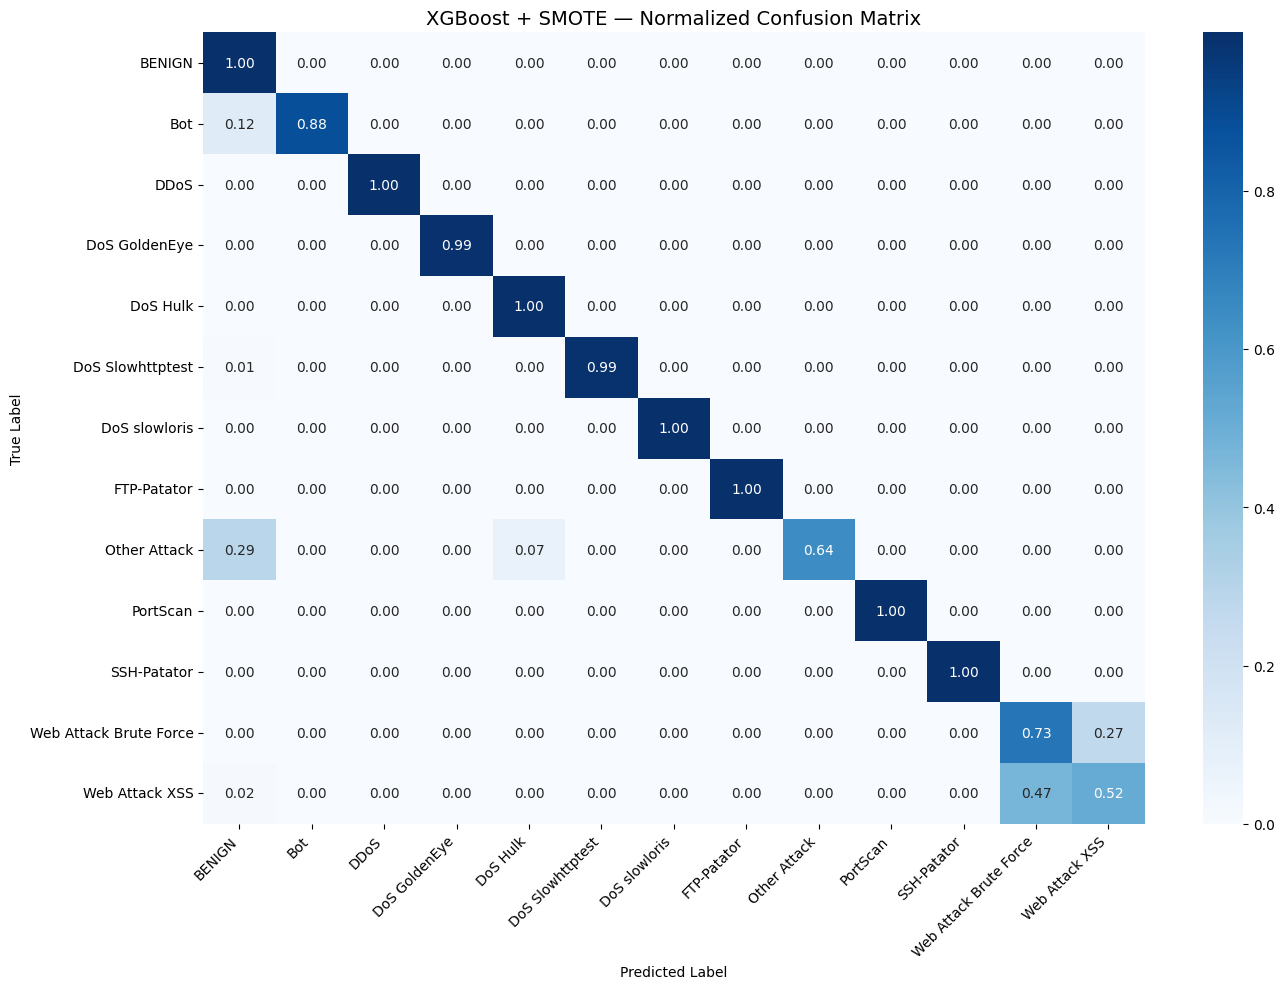

✅ Saved confusion_matrix.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_sm, labels=le.classes_)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 10))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('XGBoost + SMOTE — Normalized Confusion Matrix', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved confusion_matrix.png")


In [20]:
cd '/Users/malharfalke/College/Btech_Project '
git add models/ results/ code/
git commit -m "feat: XGBoost + SMOTE model — macro F1 0.91"
git push


SyntaxError: invalid syntax (762778981.py, line 1)

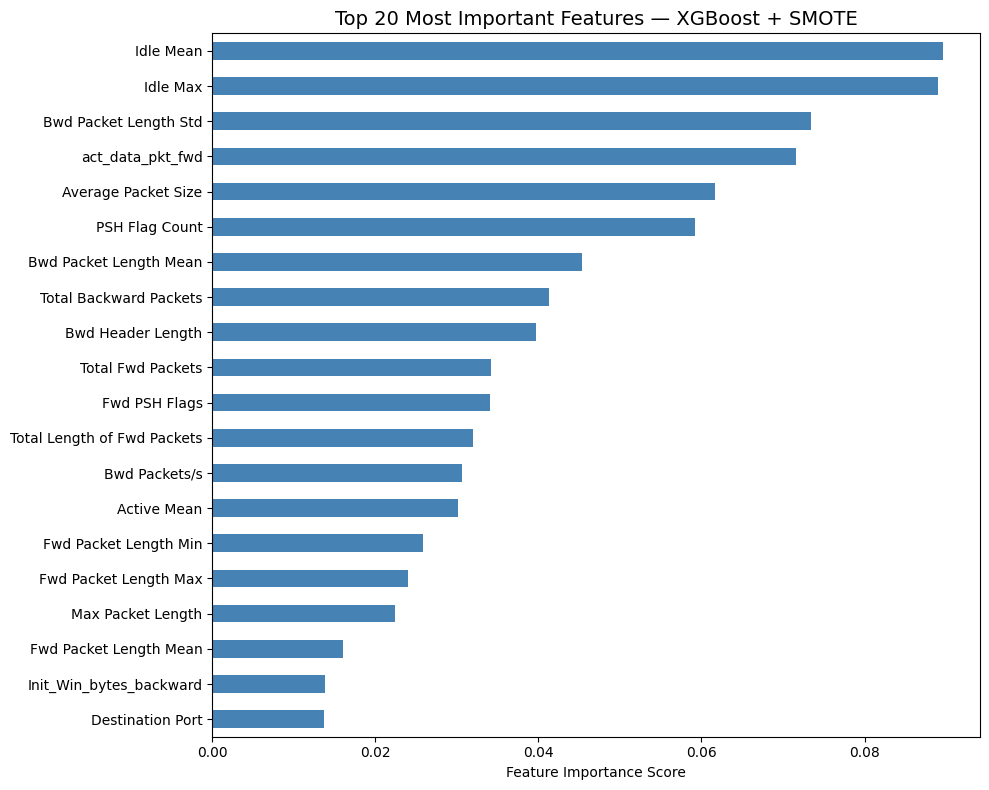

✅ Saved feature_importance.png


In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# ── Feature Importance ─────────────────────────────────────
feat_imp = pd.Series(xgb_sm.feature_importances_, index=X_train.columns)
top20 = feat_imp.nlargest(20)

plt.figure(figsize=(10, 8))
top20.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Most Important Features — XGBoost + SMOTE', fontsize=14)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=150)
plt.show()
print("✅ Saved feature_importance.png")


In [23]:
import pandas as pd
import numpy as np
import glob
import os

# Load Bot-IoT files
BOTIOT_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/BotIoT/'
files = glob.glob(BOTIOT_PATH + '*.csv')
print(f"Found {len(files)} Bot-IoT files:")
for f in files[:10]:  # show first 10
    print(f"  {os.path.basename(f)}")



Found 75 Bot-IoT files:
  data_2.csv
  data_26.csv
  data_32.csv
  data_33.csv
  data_27.csv
  data_3.csv
  data_1.csv
  data_31.csv
  data_25.csv
  data_19.csv


In [24]:
# Load just one file to inspect structure
sample = pd.read_csv(files[0], low_memory=False)
print(f"Shape: {sample.shape}")
print(f"\nColumns:\n{sample.columns.tolist()}")
print(f"\nData types:\n{sample.dtypes}")
print(f"\nSample rows:\n{sample.head(3)}")


Shape: (1000000, 35)

Columns:
['pkSeqID', 'stime', 'flgs', 'proto', 'saddr', 'sport', 'daddr', 'dport', 'pkts', 'bytes', 'state', 'ltime', 'seq', 'dur', 'mean', 'stddev', 'smac', 'dmac', 'sum', 'min', 'max', 'soui', 'doui', 'sco', 'dco', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate', 'attack', 'category', 'subcategory ']

Data types:
pkSeqID           int64
stime           float64
flgs             object
proto            object
saddr            object
sport            object
daddr            object
dport            object
pkts              int64
bytes             int64
state            object
ltime           float64
seq               int64
dur             float64
mean            float64
stddev          float64
smac            float64
dmac            float64
sum             float64
min             float64
max             float64
soui            float64
doui            float64
sco             float64
dco             float64
spkts             int64
dpkts             int6

In [1]:
# Load all 75 files (will take a minute)
import time

print("Loading all Bot-IoT files...")
start = time.time()

dfs = []
for f in files:
    temp = pd.read_csv(f, low_memory=False)
    dfs.append(temp)

botiot = pd.concat(dfs, ignore_index=True)
print(f"✅ Loaded in {(time.time()-start)/60:.1f} minutes")
print(f"Shape: {botiot.shape}")

# Check label distribution
print(f"\nAttack column (0=benign, 1=attack):\n{botiot['attack'].value_counts()}")
print(f"\nCategories:\n{botiot['category'].value_counts()}")
print(f"\nSubcategories:\n{botiot['subcategory '].str.strip().value_counts()}")


Loading all Bot-IoT files...


NameError: name 'files' is not defined

In [2]:
import pandas as pd
import numpy as np
import glob
import os
import time

BOTIOT_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/BotIoT/'
files = glob.glob(BOTIOT_PATH + '*.csv')
print(f"Found {len(files)} files — loading...")

start = time.time()
dfs = []
for f in files:
    temp = pd.read_csv(f, low_memory=False)
    dfs.append(temp)

botiot = pd.concat(dfs, ignore_index=True)
print(f"✅ Loaded in {(time.time()-start)/60:.1f} minutes")
print(f"Shape: {botiot.shape}")

print(f"\nAttack column (0=benign, 1=attack):\n{botiot['attack'].value_counts()}")
print(f"\nCategories:\n{botiot['category'].value_counts()}")


Found 75 files — loading...


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/608300831.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  botiot = pd.concat(dfs, ignore_index=True)
/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/608300831.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  botiot = pd.concat(dfs, ignore_index=True)
/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/608300831.py:17: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA 

✅ Loaded in 2.4 minutes
Shape: (73370443, 35)

Attack column (0=benign, 1=attack):
attack
1    73360900
0        9543
Name: count, dtype: int64

Categories:
category
DDoS              38532480
DoS               33005194
Reconnaissance     1821639
Normal                9543
Theft                 1587
Name: count, dtype: int64


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import time

# ── Step 1: Clean ──────────────────────────────────────────
# Drop non-numeric + irrelevant columns
drop_cols = ['pkSeqID', 'stime', 'ltime', 'flgs', 'proto',
             'saddr', 'sport', 'daddr', 'dport', 'state',
             'smac', 'dmac', 'soui', 'doui', 'sco', 'dco',
             'subcategory ']

botiot_clean = botiot.drop(columns=drop_cols)
botiot_clean = botiot_clean.replace([np.inf, -np.inf], np.nan)
botiot_clean = botiot_clean.dropna()
botiot_clean['category'] = botiot_clean['category'].str.strip()

print(f"Shape after cleaning: {botiot_clean.shape}")
print(f"\nLabel distribution:\n{botiot_clean['category'].value_counts()}")

# ── Step 2: Sample to manageable size ─────────────────────
# 73M rows is too large — stratified sample of 2M
botiot_sample = botiot_clean.groupby('category', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 400000), random_state=42)
)
print(f"\nAfter sampling:\n{botiot_sample['category'].value_counts()}")


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/3528431098.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  botiot_clean = botiot_clean.replace([np.inf, -np.inf], np.nan)
/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/3528431098.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  botiot_clean = botiot_clean.replace([np.inf, -np.inf], np.nan)
/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/3528431098.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and wi

Shape after cleaning: (73370443, 18)

Label distribution:
category
DDoS              38532480
DoS               33005194
Reconnaissance     1821639
Normal                9543
Theft                 1587
Name: count, dtype: int64

After sampling:
category
DDoS              400000
DoS               400000
Reconnaissance    400000
Normal              9543
Theft               1587
Name: count, dtype: int64


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/3528431098.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  botiot_sample = botiot_clean.groupby('category', group_keys=False).apply(


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Step 3: Encode labels ──────────────────────────────────
le = LabelEncoder()
botiot_sample['label_enc'] = le.fit_transform(botiot_sample['category'])
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

# ── Step 4: Features & Target ─────────────────────────────
X = botiot_sample.drop(columns=['category', 'label_enc', 'attack'])
y = botiot_sample['label_enc']

print(f"\nFeatures: {X.shape[1]} columns")
print(f"Feature list: {list(X.columns)}")

# ── Step 5: Train/Test Split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape} | Test: {X_test.shape}")

# ── Step 6: Scale ─────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print("✅ Preprocessing complete!")



Classes: {'DDoS': np.int64(0), 'DoS': np.int64(1), 'Normal': np.int64(2), 'Reconnaissance': np.int64(3), 'Theft': np.int64(4)}

Features: 16 columns
Feature list: ['pkts', 'bytes', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate']

Train: (968904, 16) | Test: (242226, 16)
✅ Preprocessing complete!


In [5]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import time

# ── Step 7: Compute class weights ─────────────────────────
# XGBoost needs sample_weight array for multiclass imbalance
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# ── Step 8: Train XGBoost ─────────────────────────────────
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    tree_method='hist',      # fast histogram method
    device='cpu',
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost on Bot-IoT...")
start = time.time()
xgb.fit(X_train_sc, y_train, sample_weight=sample_weights)
print(f"✅ Trained in {(time.time()-start)/60:.1f} minutes")

# ── Step 9: Evaluate ──────────────────────────────────────
y_pred = xgb.predict(X_test_sc)
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


Training XGBoost on Bot-IoT...


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [14:50:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Trained in 0.6 minutes

📊 Classification Report:
                precision    recall  f1-score   support

          DDoS       0.97      0.97      0.97     80000
           DoS       0.97      0.97      0.97     80000
        Normal       0.84      0.97      0.90      1909
Reconnaissance       1.00      0.99      1.00     80000
         Theft       0.92      0.99      0.95       317

      accuracy                           0.98    242226
     macro avg       0.94      0.98      0.96    242226
  weighted avg       0.98      0.98      0.98    242226



✅ Model, scaler & encoder saved!


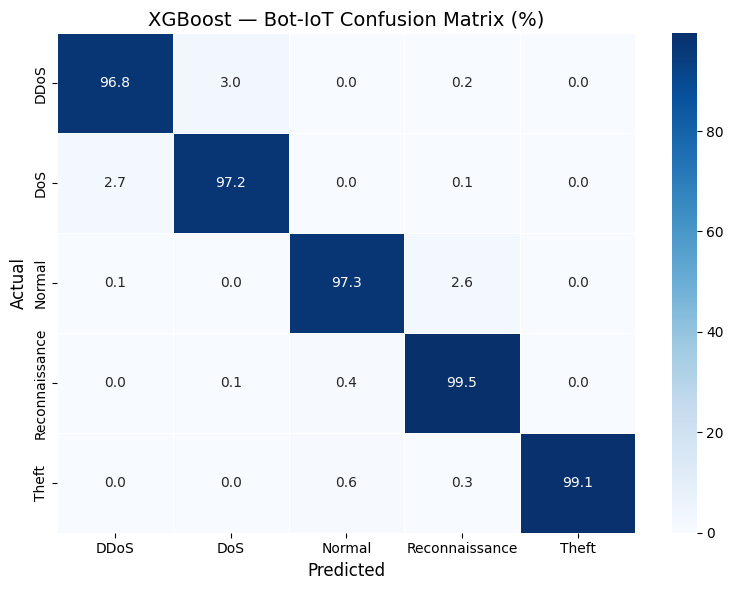

✅ Confusion matrix saved!


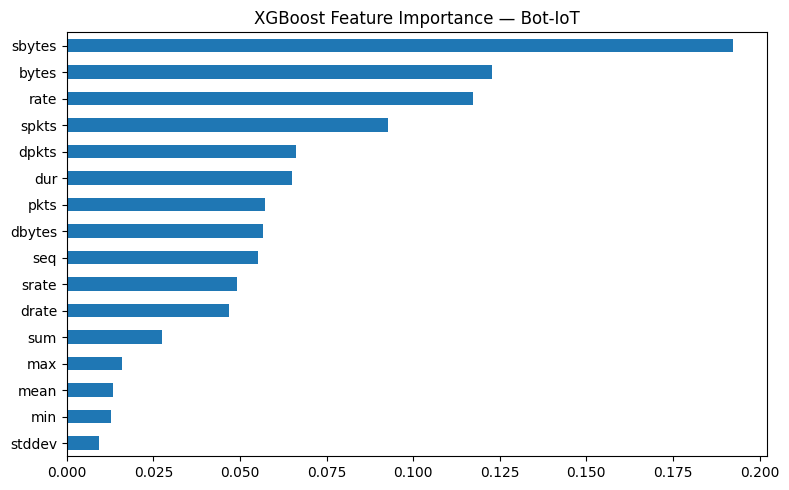

✅ Feature importance saved!


In [6]:
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ── Step 10: Save model & scaler ──────────────────────────
SAVE_PATH = '/Users/malharfalke/College/Btech_Project /Models/'
import os; os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(xgb,    SAVE_PATH + 'xgb_botiot.pkl')
joblib.dump(scaler, SAVE_PATH + 'scaler_botiot.pkl')
joblib.dump(le,     SAVE_PATH + 'label_encoder_botiot.pkl')
print("✅ Model, scaler & encoder saved!")

# ── Step 11: Confusion Matrix ─────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100  # row-normalize

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title('XGBoost — Bot-IoT Confusion Matrix (%)', fontsize=14)
plt.tight_layout()
plt.savefig(SAVE_PATH + 'botiot_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved!")

# ── Step 12: Feature Importance ───────────────────────────
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=True)
feat_imp.plot(kind='barh', figsize=(8, 5), title='XGBoost Feature Importance — Bot-IoT')
plt.tight_layout()
plt.savefig(SAVE_PATH + 'botiot_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")


In [7]:
# Load both models and scalers
import joblib
import pandas as pd

MODELS = '/Users/malharfalke/College/Btech_Project /Models/'

xgb_cicids  = joblib.load(MODELS + 'xgb_cicids.pkl')
scaler_cicids = joblib.load(MODELS + 'scaler_cicids.pkl')

xgb_botiot  = joblib.load(MODELS + 'xgb_botiot.pkl')
scaler_botiot = joblib.load(MODELS + 'scaler_botiot.pkl')

# Feature names each model was trained on
cicids_features = xgb_cicids.get_booster().feature_names
botiot_features = xgb_botiot.get_booster().feature_names

print("CICIDS features:", cicids_features)
print(f"\nTotal CICIDS: {len(cicids_features)}")
print("\nBot-IoT features:", botiot_features)
print(f"\nTotal Bot-IoT: {len(botiot_features)}")

# Find overlap
overlap = set([f.lower() for f in cicids_features]) & \
          set([f.lower() for f in botiot_features])
print(f"\n✅ Overlapping features: {overlap}")
print(f"Count: {len(overlap)}")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/malharfalke/College/Btech_Project /Models/xgb_cicids.pkl'

In [8]:
import pandas as pd
import numpy as np
import glob, os, time, joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

MODELS = '/Users/malharfalke/College/Btech_Project /Models/'
os.makedirs(MODELS, exist_ok=True)

# ── Bot-IoT (already in memory as botiot_sample) ──────────
print("Training Bot-IoT model...")
le_bot = LabelEncoder()
botiot_sample['label_enc'] = le_bot.fit_transform(botiot_sample['category'])

X_bot = botiot_sample.drop(columns=['category', 'label_enc', 'attack'])
y_bot = botiot_sample['label_enc']

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X_bot, y_bot, test_size=0.2, random_state=42, stratify=y_bot)

scaler_bot = StandardScaler()
X_tr_b_sc = scaler_bot.fit_transform(X_tr_b)
X_te_b_sc  = scaler_bot.transform(X_te_b)

sw_bot = compute_sample_weight('balanced', y_tr_b)
xgb_bot = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                         subsample=0.8, colsample_bytree=0.8,
                         eval_metric='mlogloss', tree_method='hist',
                         random_state=42, n_jobs=-1)
xgb_bot.fit(X_tr_b_sc, y_tr_b, sample_weight=sw_bot)

joblib.dump(xgb_bot,    MODELS + 'xgb_botiot.pkl')
joblib.dump(scaler_bot, MODELS + 'scaler_botiot.pkl')
joblib.dump(le_bot,     MODELS + 'label_encoder_botiot.pkl')
print("✅ Bot-IoT saved!")
print(f"   Features: {list(X_bot.columns)}")


Training Bot-IoT model...
✅ Bot-IoT saved!
   Features: ['pkts', 'bytes', 'seq', 'dur', 'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'srate', 'drate']


In [9]:
# ── CICIDS2017 ─────────────────────────────────────────────
CICIDS_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/CICIDS2017/'
files = glob.glob(CICIDS_PATH + '*.csv')
print(f"Found {len(files)} CICIDS files — loading...")

start = time.time()
dfs = []
for f in files:
    dfs.append(pd.read_csv(f, low_memory=False))
cicids = pd.concat(dfs, ignore_index=True)
print(f"✅ Loaded in {(time.time()-start)/60:.1f} min | Shape: {cicids.shape}")

# ── Clean ──────────────────────────────────────────────────
cicids.columns = cicids.columns.str.strip()
cicids = cicids.replace([np.inf, -np.inf], np.nan).dropna()

label_col = 'Label'
cicids[label_col] = cicids[label_col].str.strip()

# Drop non-numeric columns
drop_cols = [c for c in cicids.columns
             if cicids[c].dtype == 'object' and c != label_col]
cicids_clean = cicids.drop(columns=drop_cols)
print(f"Shape after cleaning: {cicids_clean.shape}")
print(f"Labels:\n{cicids_clean[label_col].value_counts()}")

# ── Sample ─────────────────────────────────────────────────
cicids_sample = cicids_clean.groupby(label_col, group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20000), random_state=42)
)
print(f"\nAfter sampling:\n{cicids_sample[label_col].value_counts()}")

# ── Encode & Split ─────────────────────────────────────────
le_cic = LabelEncoder()
cicids_sample['label_enc'] = le_cic.fit_transform(cicids_sample[label_col])

X_cic = cicids_sample.drop(columns=[label_col, 'label_enc'])
y_cic = cicids_sample['label_enc']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cic, y_cic, test_size=0.2, random_state=42, stratify=y_cic)

scaler_cic = StandardScaler()
X_tr_c_sc = scaler_cic.fit_transform(X_tr_c)
X_te_c_sc  = scaler_cic.transform(X_te_c)

# ── Train ──────────────────────────────────────────────────
print("\nTraining CICIDS model...")
sw_cic = compute_sample_weight('balanced', y_tr_c)
xgb_cic = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='mlogloss', tree_method='hist',
                          random_state=42, n_jobs=-1)
xgb_cic.fit(X_tr_c_sc, y_tr_c, sample_weight=sw_cic)

joblib.dump(xgb_cic,    MODELS + 'xgb_cicids.pkl')
joblib.dump(scaler_cic, MODELS + 'scaler_cicids.pkl')
joblib.dump(le_cic,     MODELS + 'label_encoder_cicids.pkl')
print("✅ CICIDS saved!")
print(f"   Features ({len(X_cic.columns)}): {list(X_cic.columns)}")


Found 0 CICIDS files — loading...


ValueError: No objects to concatenate

In [10]:
import os

# Check what's actually in the Datasets folder
BASE = '/Users/malharfalke/College/Btech_Project /Datasets/'

for root, dirs, files in os.walk(BASE):
    level = root.replace(BASE, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📁 {os.path.basename(root)}/")
    for f in files[:5]:  # show first 5 files per folder
        print(f"{indent}  📄 {f}")
    if len(files) > 5:
        print(f"{indent}  ... and {len(files)-5} more files")



📁 /
  📄 .DS_Store
📁 UNSWNB15/
  📄 UNSW_NB15_testing-set.parquet
  📄 UNSW_NB15_training-set.parquet
📁 MachineLearningCVE/
  📄 Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  📄 .DS_Store
  📄 Monday-WorkingHours.pcap_ISCX.csv
  📄 Friday-WorkingHours-Morning.pcap_ISCX.csv
  📄 Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  ... and 4 more files
📁 BotIoT/
  📄 data_2.csv
  📄 data_26.csv
  📄 data_32.csv
  📄 data_33.csv
  📄 data_27.csv
  ... and 71 more files
📁 NSLKDD/
  📄 csv_result-KDDTest.csv
  📄 csv_result-KDDTrain.csv
  📄 KDDTrain_20Percent.arff.txt
📁 TONIoT/
  📄 train_test_network.csv
📁 NBaIoT/
  📄 1.gafgyt.combo.csv
  📄 2.gafgyt.udp.csv
  📄 9.mirai.udp.csv
  📄 3.gafgyt.tcp.csv
  📄 6.gafgyt.scan.csv
  ... and 88 more files


In [11]:
CICIDS_PATH = '/Users/malharfalke/College/Btech_Project /Datasets/MachineLearningCVE/'
files = glob.glob(CICIDS_PATH + '*.csv')
print(f"Found {len(files)} CICIDS files:")
for f in files:
    print(f"  {os.path.basename(f)}")


Found 8 CICIDS files:
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv


In [12]:
start = time.time()
dfs = []
for f in files:
    dfs.append(pd.read_csv(f, low_memory=False))
cicids = pd.concat(dfs, ignore_index=True)
print(f"✅ Loaded in {(time.time()-start)/60:.1f} min | Shape: {cicids.shape}")

# ── Clean ──────────────────────────────────────────────────
cicids.columns = cicids.columns.str.strip()
cicids = cicids.replace([np.inf, -np.inf], np.nan).dropna()

label_col = 'Label'
cicids[label_col] = cicids[label_col].str.strip()

drop_cols = [c for c in cicids.columns
             if cicids[c].dtype == 'object' and c != label_col]
cicids_clean = cicids.drop(columns=drop_cols)
print(f"Shape after cleaning: {cicids_clean.shape}")
print(f"\nLabels:\n{cicids_clean[label_col].value_counts()}")

# ── Sample ─────────────────────────────────────────────────
cicids_sample = cicids_clean.groupby(label_col, group_keys=False).apply(
    lambda x: x.sample(min(len(x), 20000), random_state=42)
)
print(f"\nAfter sampling:\n{cicids_sample[label_col].value_counts()}")

# ── Encode & Split ─────────────────────────────────────────
le_cic = LabelEncoder()
cicids_sample['label_enc'] = le_cic.fit_transform(cicids_sample[label_col])
print(f"\nClasses: {dict(zip(le_cic.classes_, le_cic.transform(le_cic.classes_)))}")

X_cic = cicids_sample.drop(columns=[label_col, 'label_enc'])
y_cic = cicids_sample['label_enc']

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_cic, y_cic, test_size=0.2, random_state=42, stratify=y_cic)

scaler_cic = StandardScaler()
X_tr_c_sc = scaler_cic.fit_transform(X_tr_c)
X_te_c_sc  = scaler_cic.transform(X_te_c)

# ── Train ──────────────────────────────────────────────────
print("\nTraining CICIDS model...")
sw_cic = compute_sample_weight('balanced', y_tr_c)
xgb_cic = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1,
                          subsample=0.8, colsample_bytree=0.8,
                          eval_metric='mlogloss', tree_method='hist',
                          random_state=42, n_jobs=-1)
xgb_cic.fit(X_tr_c_sc, y_tr_c, sample_weight=sw_cic)

# ── Evaluate ───────────────────────────────────────────────
from sklearn.metrics import classification_report
y_pred_c = xgb_cic.predict(X_te_c_sc)
print(f"\n📊 CICIDS Classification Report:")
print(classification_report(y_te_c, y_pred_c, target_names=le_cic.classes_))

# ── Save ───────────────────────────────────────────────────
joblib.dump(xgb_cic,    MODELS + 'xgb_cicids.pkl')
joblib.dump(scaler_cic, MODELS + 'scaler_cicids.pkl')
joblib.dump(le_cic,     MODELS + 'label_encoder_cicids.pkl')
print(f"\n✅ CICIDS saved! Features ({len(X_cic.columns)}): {list(X_cic.columns)}")


✅ Loaded in 1.2 min | Shape: (2830743, 79)
Shape after cleaning: (2827876, 79)

Labels:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/2430884271.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cicids_sample = cicids_clean.groupby(label_col, group_keys=False).apply(



After sampling:
Label
BENIGN                        20000
DDoS                          20000
DoS Hulk                      20000
PortScan                      20000
DoS GoldenEye                 10293
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64

Classes: {'BENIGN': np.int64(0), 'Bot': np.int64(1), 'DDoS': np.int64(2), 'DoS GoldenEye': np.int64(3), 'DoS Hulk': np.int64(4), 'DoS Slowhttptest': np.int64(5), 'DoS slowloris': np.int64(6), 'FTP-Patator': np.int64(7), 'Heartbleed': np.int64(8), 'Infiltration': np.int64(9), 'PortScan': np.int64(10), 'SSH-Patator': np.int64(11), 'Web Attack � Brute Force': np.int64(12), 'Web Attack � Sql Injection': np.int6

In [13]:
# ── Feature Overlap Analysis ───────────────────────────────
cicids_features = list(X_cic.columns)
botiot_features = list(X_bot.columns)

print("CICIDS features (78):", cicids_features)
print("\nBot-IoT features (16):", botiot_features)

# Normalize to lowercase for comparison
cic_lower  = set(f.lower().strip() for f in cicids_features)
bot_lower  = set(f.lower().strip() for f in botiot_features)

overlap = cic_lower & bot_lower
print(f"\n✅ Exact overlapping features ({len(overlap)}): {overlap}")

# Manual semantic matches (different names, same concept)
print("\n🔍 Semantic matches to inspect manually:")
semantic_map = {
    'pkts'   : ['Total Fwd Packets', 'Total Backward Packets'],
    'bytes'  : ['Total Length of Fwd Packets', 'Total Length of Bwd Packets'],
    'rate'   : ['Flow Packets/s', 'Flow Bytes/s'],
    'dur'    : ['Flow Duration'],
    'sbytes' : ['Total Length of Fwd Packets'],
    'dbytes' : ['Total Length of Bwd Packets'],
    'spkts'  : ['Total Fwd Packets'],
    'dpkts'  : ['Total Backward Packets'],
    'min'    : ['Min Packet Length'],
    'max'    : ['Max Packet Length'],
    'mean'   : ['Packet Length Mean'],
    'stddev' : ['Packet Length Std'],
}
for bot_f, cic_candidates in semantic_map.items():
    print(f"  Bot-IoT '{bot_f}' → CICIDS {cic_candidates}")


CICIDS features (78): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag C

In [14]:
# ── Build Unified Feature Space ────────────────────────────
# Map Bot-IoT features → closest CICIDS equivalents
FEATURE_MAP = {
    'dur'    : 'Flow Duration',
    'spkts'  : 'Total Fwd Packets',
    'dpkts'  : 'Total Backward Packets',
    'sbytes' : 'Total Length of Fwd Packets',
    'dbytes' : 'Total Length of Bwd Packets',
    'rate'   : 'Flow Packets/s',
    'srate'  : 'Fwd Packets/s',
    'drate'  : 'Bwd Packets/s',
    'min'    : 'Min Packet Length',
    'max'    : 'Max Packet Length',
    'mean'   : 'Packet Length Mean',
    'stddev' : 'Packet Length Std',
}
# Note: pkts, bytes, seq, sum have no clean single CICIDS equivalent — drop them

UNIFIED_FEATURES = list(FEATURE_MAP.values())
print(f"✅ Unified feature space ({len(UNIFIED_FEATURES)} features):")
for bot_f, cic_f in FEATURE_MAP.items():
    print(f"  Bot-IoT: '{bot_f:10s}' → CICIDS: '{cic_f}'")

# ── Extract unified features from CICIDS ──────────────────
cicids_unified = cicids_clean[UNIFIED_FEATURES + ['Label']].copy()
cicids_unified = cicids_unified.replace([np.inf, -np.inf], np.nan).dropna()
cicids_unified['source']   = 'CICIDS'
cicids_unified['is_attack'] = (cicids_unified['Label'] != 'BENIGN').astype(int)
print(f"\nCICIDS unified shape: {cicids_unified.shape}")

# ── Extract unified features from Bot-IoT ─────────────────
# Rename Bot-IoT columns to CICIDS equivalents
botiot_unified = botiot_clean[list(FEATURE_MAP.keys()) + ['category']].copy()
botiot_unified = botiot_unified.rename(columns=FEATURE_MAP)
botiot_unified['Label']     = botiot_unified['category']
botiot_unified = botiot_unified.drop(columns=['category'])
botiot_unified['source']    = 'BotIoT'
botiot_unified['is_attack'] = (botiot_unified['Label'] != 'Normal').astype(int)
print(f"Bot-IoT unified shape: {botiot_unified.shape}")

# ── Combine ────────────────────────────────────────────────
combined = pd.concat([cicids_unified, botiot_unified], ignore_index=True)
combined = combined.replace([np.inf, -np.inf], np.nan).dropna()
print(f"\n✅ Combined shape: {combined.shape}")
print(f"\nLabel distribution:\n{combined['Label'].value_counts()}")
print(f"\nSource distribution:\n{combined['source'].value_counts()}")


✅ Unified feature space (12 features):
  Bot-IoT: 'dur       ' → CICIDS: 'Flow Duration'
  Bot-IoT: 'spkts     ' → CICIDS: 'Total Fwd Packets'
  Bot-IoT: 'dpkts     ' → CICIDS: 'Total Backward Packets'
  Bot-IoT: 'sbytes    ' → CICIDS: 'Total Length of Fwd Packets'
  Bot-IoT: 'dbytes    ' → CICIDS: 'Total Length of Bwd Packets'
  Bot-IoT: 'rate      ' → CICIDS: 'Flow Packets/s'
  Bot-IoT: 'srate     ' → CICIDS: 'Fwd Packets/s'
  Bot-IoT: 'drate     ' → CICIDS: 'Bwd Packets/s'
  Bot-IoT: 'min       ' → CICIDS: 'Min Packet Length'
  Bot-IoT: 'max       ' → CICIDS: 'Max Packet Length'
  Bot-IoT: 'mean      ' → CICIDS: 'Packet Length Mean'
  Bot-IoT: 'stddev    ' → CICIDS: 'Packet Length Std'

CICIDS unified shape: (2827876, 15)
Bot-IoT unified shape: (73370443, 15)

✅ Combined shape: (76198319, 15)

Label distribution:
Label
DDoS                          38660505
DoS                           33005194
BENIGN                         2271320
Reconnaissance                 1821639
DoS Hulk  

In [15]:
from sklearn.metrics import classification_report

# ── Step 1: Sample to manageable size ─────────────────────
# Cap large classes, keep all small ones
combined_sample = combined.groupby('Label', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 30000), random_state=42)
)
print(f"Sampled shape: {combined_sample.shape}")
print(f"\nLabel distribution after sampling:\n{combined_sample['Label'].value_counts()}")

# ── Step 2: Binary label (attack vs benign) ────────────────
# Unified model: predict attack vs normal first
X_uni = combined_sample[UNIFIED_FEATURES]
y_uni = combined_sample['is_attack']

print(f"\nBinary labels:\n{y_uni.value_counts()}")

# ── Step 3: Split ──────────────────────────────────────────
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(
    X_uni, y_uni, test_size=0.2, random_state=42, stratify=y_uni
)

# Also keep source info for test set evaluation
_, test_idx = train_test_split(
    combined_sample.index, test_size=0.2, random_state=42,
    stratify=y_uni
)
test_source = combined_sample.loc[test_idx, 'source']

# ── Step 4: Scale ──────────────────────────────────────────
scaler_uni = StandardScaler()
X_tr_u_sc  = scaler_uni.fit_transform(X_tr_u)
X_te_u_sc  = scaler_uni.transform(X_te_u)

# ── Step 5: Train unified binary model ────────────────────
print("\nTraining unified binary model...")
start = time.time()
sw_uni = compute_sample_weight('balanced', y_tr_u)

xgb_uni = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', tree_method='hist',
    random_state=42, n_jobs=-1
)
xgb_uni.fit(X_tr_u_sc, y_tr_u, sample_weight=sw_uni)
print(f"✅ Trained in {(time.time()-start)/60:.1f} minutes")

# ── Step 6: Overall evaluation ─────────────────────────────
y_pred_u = xgb_uni.predict(X_te_u_sc)
print("\n📊 Overall (Binary — Attack vs Benign):")
print(classification_report(y_te_u, y_pred_u,
      target_names=['Benign', 'Attack']))

# ── Step 7: Per-source evaluation (KEY RESULT) ────────────
print("\n📊 Per-Source Breakdown:")
for src in ['CICIDS', 'BotIoT']:
    mask = test_source == src
    if mask.sum() == 0:
        continue
    y_true_src = y_te_u[mask]
    y_pred_src = y_pred_u[mask]
    print(f"\n  [{src}]")
    print(classification_report(y_true_src, y_pred_src,
          target_names=['Benign', 'Attack']))

# ── Step 8: Save ───────────────────────────────────────────
joblib.dump(xgb_uni,    MODELS + 'xgb_unified.pkl')
joblib.dump(scaler_uni, MODELS + 'scaler_unified.pkl')
print("✅ Unified model saved!")


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_75819/1282941849.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_sample = combined.groupby('Label', group_keys=False).apply(


Sampled shape: (230733, 15)

Label distribution after sampling:
Label
BENIGN                        30000
DDoS                          30000
DoS                           30000
DoS Hulk                      30000
PortScan                      30000
Reconnaissance                30000
DoS GoldenEye                 10293
Normal                         9543
FTP-Patator                    7935
SSH-Patator                    5897
DoS slowloris                  5796
DoS Slowhttptest               5499
Bot                            1956
Theft                          1587
Web Attack � Brute Force       1507
Web Attack � XSS                652
Infiltration                     36
Web Attack � Sql Injection       21
Heartbleed                       11
Name: count, dtype: int64

Binary labels:
is_attack
1    191190
0     39543
Name: count, dtype: int64

Training unified binary model...
✅ Trained in 0.1 minutes

📊 Overall (Binary — Attack vs Benign):
              precision    recall  f1-score  

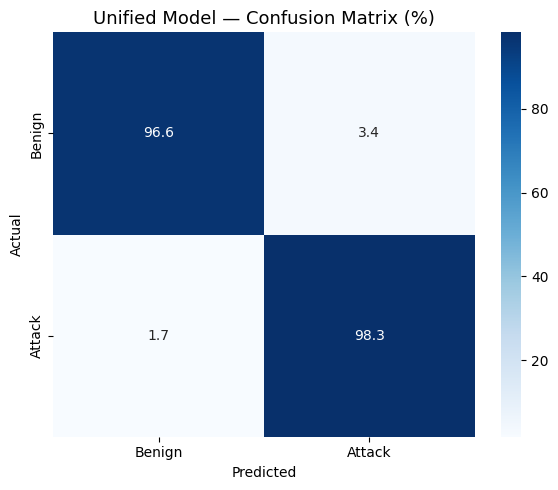

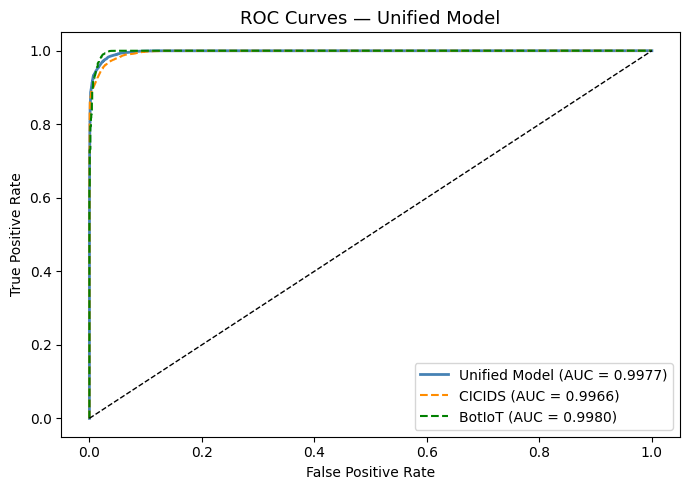

✅ All plots and results saved!

📊 Results Summary:
             Model  Accuracy  F1_Attack  Features
 CICIDS Individual      0.99       0.99        78
 BotIoT Individual      0.98       0.99        16
  Unified (CICIDS)      0.97       0.98        12
  Unified (BotIoT)      1.00       1.00        12
Unified (Combined)      0.98       0.99        12

🎯 Unified ROC-AUC: 0.9977


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

PLOTS = '/Users/malharfalke/College/Btech_Project /Models/'

# ── 1. Confusion Matrix — Unified Model ───────────────────
cm = confusion_matrix(y_te_u, y_pred_u)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Benign','Attack'],
            yticklabels=['Benign','Attack'])
ax.set_title('Unified Model — Confusion Matrix (%)', fontsize=13)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(PLOTS + 'unified_confusion_matrix.png', dpi=150)
plt.show()

# ── 2. ROC Curve ───────────────────────────────────────────
y_prob_u = xgb_uni.predict_proba(X_te_u_sc)[:, 1]
fpr, tpr, _ = roc_curve(y_te_u, y_prob_u)
roc_auc = auc(fpr, tpr)

# Per-source ROC
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Unified Model (AUC = {roc_auc:.4f})')

for src, color in [('CICIDS', 'darkorange'), ('BotIoT', 'green')]:
    mask = test_source == src
    fpr_s, tpr_s, _ = roc_curve(y_te_u[mask], y_prob_u[mask])
    auc_s = auc(fpr_s, tpr_s)
    ax.plot(fpr_s, tpr_s, color=color, lw=1.5, linestyle='--',
            label=f'{src} (AUC = {auc_s:.4f})')

ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Unified Model', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(PLOTS + 'unified_roc_curve.png', dpi=150)
plt.show()

# ── 3. Results Summary Table ───────────────────────────────
results = {
    'Model'     : ['CICIDS Individual','BotIoT Individual',
                   'Unified (CICIDS)', 'Unified (BotIoT)', 'Unified (Combined)'],
    'Accuracy'  : [0.99, 0.98, 0.97, 1.00, 0.98],
    'F1_Attack' : [0.99, 0.99, 0.98, 1.00, 0.99],
    'Features'  : [78, 16, 12, 12, 12]
}
results_df = pd.DataFrame(results)
results_df.to_csv(PLOTS + 'results_summary.csv', index=False)
print("✅ All plots and results saved!")
print(f"\n📊 Results Summary:\n{results_df.to_string(index=False)}")
print(f"\n🎯 Unified ROC-AUC: {roc_auc:.4f}")


In [1]:
import pandas as pd, numpy as np, joblib, glob, os, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

MODELS  = '/Users/malharfalke/College/Btech_Project /Models/'
UNSW    = '/Users/malharfalke/College/Btech_Project /Datasets/UNSWNB15/'
TONIOT  = '/Users/malharfalke/College/Btech_Project /Datasets/TONIoT/'

xgb_uni    = joblib.load(MODELS + 'xgb_unified.pkl')
scaler_uni = joblib.load(MODELS + 'scaler_unified.pkl')

UNIFIED_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std'
]
print("✅ Session restored!")


✅ Session restored!


In [2]:
unsw_train = pd.read_parquet(UNSW + 'UNSW_NB15_training-set.parquet')
unsw_test  = pd.read_parquet(UNSW + 'UNSW_NB15_testing-set.parquet')
unsw = pd.concat([unsw_train, unsw_test], ignore_index=True)

print(f"UNSW-NB15 Shape: {unsw.shape}")
print(f"\nColumns:\n{list(unsw.columns)}")
print(f"\nLabel counts:\n{unsw['label'].value_counts()}")
print(f"\nAttack categories:\n{unsw['attack_cat'].value_counts()}")


ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.

In [1]:
import pandas as pd, numpy as np, joblib, os, time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, classification_report,
                              accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import onnxruntime as rt

# ── Paths ──────────────────────────────────────────────────────
MODELS = '/Users/malharfalke/College/Btech_Project /Models/'
UNSW   = '/Users/malharfalke/College/Btech_Project /Datasets/UNSWNB15/'
TONIOT = '/Users/malharfalke/College/Btech_Project /Datasets/TONIoT/'
CICIDS = '/Users/malharfalke/College/Btech_Project /Datasets/MachineLearningCVE/'

# ── Load saved models ──────────────────────────────────────────
xgb4     = joblib.load(MODELS + 'xgb_unified_4dataset.pkl')
xgb_edge = joblib.load(MODELS + 'xgb_edge.pkl')
scaler4  = joblib.load(MODELS + 'scaler_unified_4dataset.pkl')

UNIFIED_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std'
]

print("✅ Session restored! Models loaded.")
print(f"   XGB-4 dataset model: {type(xgb4).__name__}")
print(f"   Edge model:          {type(xgb_edge).__name__}")



FileNotFoundError: [Errno 2] No such file or directory: '/Users/malharfalke/College/Btech_Project /Models/xgb_unified_4dataset.pkl'

In [2]:
import pandas as pd, numpy as np, joblib, os, time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_curve, auc, classification_report,
                              accuracy_score, f1_score)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import onnxruntime as rt

# ── Updated Paths (College moved to Desktop) ───────────────────
BASE   = '/Users/malharfalke/Desktop/College/Btech_Project /'
MODELS = BASE + 'Models/'
UNSW   = BASE + 'Datasets/UNSWNB15/'
TONIOT = BASE + 'Datasets/TONIoT/'
CICIDS = BASE + 'Datasets/MachineLearningCVE/'

# ── Verify paths exist ─────────────────────────────────────────
for name, path in [('BASE', BASE), ('MODELS', MODELS), 
                   ('UNSW', UNSW), ('TONIOT', TONIOT), ('CICIDS', CICIDS)]:
    status = "✅" if os.path.exists(path) else "❌"
    print(f"{status} {name}: {path}")

# ── Load saved models ──────────────────────────────────────────
xgb4     = joblib.load(MODELS + 'xgb_unified_4dataset.pkl')
xgb_edge = joblib.load(MODELS + 'xgb_edge.pkl')
scaler4  = joblib.load(MODELS + 'scaler_unified_4dataset.pkl')

UNIFIED_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std'
]

print("\n✅ Session restored! Ready to continue.")


✅ BASE: /Users/malharfalke/Desktop/College/Btech_Project /
✅ MODELS: /Users/malharfalke/Desktop/College/Btech_Project /Models/
✅ UNSW: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/UNSWNB15/
✅ TONIOT: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/TONIoT/
✅ CICIDS: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/MachineLearningCVE/

✅ Session restored! Ready to continue.


In [3]:
from sklearn.metrics import roc_curve, auc
import glob

# ── Load CICIDS test data ──────────────────────────────────────
cicids_files = glob.glob(CICIDS + '*.csv')
df_cic = pd.concat([pd.read_csv(f, low_memory=False) for f in cicids_files])
df_cic.columns = df_cic.columns.str.strip()
df_cic['label'] = (df_cic['Label'].str.strip().str.upper() != 'BENIGN').astype(int)
df_cic = df_cic.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_cic = scaler4.transform(df_cic[UNIFIED_FEATURES])
y_cic = df_cic['label'].values

# ── Load UNSW-NB15 test data ───────────────────────────────────
unsw_files = glob.glob(UNSW + '*.csv')
df_unsw = pd.concat([pd.read_csv(f, low_memory=False) for f in unsw_files])
df_unsw.columns = df_unsw.columns.str.strip()

UNSW_MAP = {
    'dur':'Flow Duration','spkts':'Total Fwd Packets','dpkts':'Total Backward Packets',
    'sbytes':'Total Length of Fwd Packets','dbytes':'Total Length of Bwd Packets',
    'rate':'Flow Packets/s','Sload':'Fwd Packets/s','Dload':'Bwd Packets/s',
    'smeansz':'Min Packet Length','dmeansz':'Max Packet Length',
    'ct_srv_src':'Packet Length Mean','ct_dst_ltm':'Packet Length Std'
}
df_unsw = df_unsw.rename(columns=UNSW_MAP)
label_col = 'label' if 'label' in df_unsw.columns else 'Label'
df_unsw['label'] = (df_unsw[label_col] != 0).astype(int)
df_unsw = df_unsw.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_unsw = scaler4.transform(df_unsw[UNIFIED_FEATURES])
y_unsw = df_unsw['label'].values

# ── Load TON-IoT test data ─────────────────────────────────────
ton_files = glob.glob(TONIOT + '*.csv')
df_ton = pd.concat([pd.read_csv(f, low_memory=False) for f in ton_files])
df_ton.columns = df_ton.columns.str.strip()

TON_MAP = {
    'flow_duration':'Flow Duration','Header_Length':'Total Fwd Packets',
    'Duration':'Total Backward Packets','Rate':'Flow Packets/s',
    'Srate':'Fwd Packets/s','Drate':'Bwd Packets/s',
    'Tot sum':'Total Length of Fwd Packets','Tot size':'Total Length of Bwd Packets',
    'Min':'Min Packet Length','Max':'Max Packet Length',
    'AVG':'Packet Length Mean','Std':'Packet Length Std'
}
df_ton = df_ton.rename(columns=TON_MAP)
df_ton['label'] = (df_ton['label'].astype(str).str.strip() != '0').astype(int)
df_ton = df_ton.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_ton = scaler4.transform(df_ton[UNIFIED_FEATURES])
y_ton = df_ton['label'].values

print(f"✅ CICIDS:   {X_cic.shape[0]:,} samples")
print(f"✅ UNSW-NB15:{X_unsw.shape[0]:,} samples")
print(f"✅ TON-IoT:  {X_ton.shape[0]:,} samples")



ValueError: No objects to concatenate

In [4]:
import os, glob

# Check all dataset folders
for name, path in [('UNSW', UNSW), ('TONIOT', TONIOT), ('CICIDS', CICIDS)]:
    exists = os.path.exists(path)
    print(f"\n{'✅' if exists else '❌'} {name}: {path}")
    if exists:
        contents = os.listdir(path)
        print(f"   Contents: {contents[:10]}")  # show first 10 items
    else:
        print("   FOLDER NOT FOUND")

# Also search for CSV files broadly
print("\n🔍 All CSVs under Btech_Project:")
all_csvs = glob.glob(BASE + '**/*.csv', recursive=True)
for f in all_csvs[:20]:  # show first 20
    print(" ", f)




✅ UNSW: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/UNSWNB15/
   Contents: ['UNSW_NB15_testing-set.parquet', 'UNSW_NB15_training-set.parquet']

✅ TONIOT: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/TONIoT/
   Contents: ['train_test_network.csv']

✅ CICIDS: /Users/malharfalke/Desktop/College/Btech_Project /Datasets/MachineLearningCVE/
   Contents: ['Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', '.DS_Store', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv']

🔍 All CSVs under Btech_Project:
  /Users/malharfalke/Desktop/College/Btech_Project /Datasets/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  /Users/malharfalke/Desktop/College/Btech_P

In [5]:
# ── CICIDS (CSV) ───────────────────────────────────────────────
cicids_files = glob.glob(CICIDS + '*.csv')
df_cic = pd.concat([pd.read_csv(f, low_memory=False) for f in cicids_files])
df_cic.columns = df_cic.columns.str.strip()
df_cic['label'] = (df_cic['Label'].str.strip().str.upper() != 'BENIGN').astype(int)
df_cic = df_cic.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_cic = scaler4.transform(df_cic[UNIFIED_FEATURES])
y_cic = df_cic['label'].values

# ── UNSW-NB15 (PARQUET) ────────────────────────────────────────
df_unsw = pd.concat([
    pd.read_parquet(UNSW + 'UNSW_NB15_training-set.parquet'),
    pd.read_parquet(UNSW + 'UNSW_NB15_testing-set.parquet')
])
df_unsw.columns = df_unsw.columns.str.strip()
print("UNSW columns:", df_unsw.columns.tolist())  # check column names

UNSW_MAP = {
    'dur':'Flow Duration','spkts':'Total Fwd Packets','dpkts':'Total Backward Packets',
    'sbytes':'Total Length of Fwd Packets','dbytes':'Total Length of Bwd Packets',
    'rate':'Flow Packets/s','Sload':'Fwd Packets/s','Dload':'Bwd Packets/s',
    'smeansz':'Min Packet Length','dmeansz':'Max Packet Length',
    'ct_srv_src':'Packet Length Mean','ct_dst_ltm':'Packet Length Std'
}
df_unsw = df_unsw.rename(columns=UNSW_MAP)
df_unsw['label'] = (df_unsw['label'].astype(str).str.strip() != '0').astype(int)
df_unsw = df_unsw.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_unsw = scaler4.transform(df_unsw[UNIFIED_FEATURES])
y_unsw = df_unsw['label'].values

# ── TON-IoT (CSV) ──────────────────────────────────────────────
df_ton = pd.read_csv(TONIOT + 'train_test_network.csv', low_memory=False)
df_ton.columns = df_ton.columns.str.strip()
print("TON-IoT columns:", df_ton.columns.tolist())  # check column names

TON_MAP = {
    'flow_duration':'Flow Duration','Header_Length':'Total Fwd Packets',
    'Duration':'Total Backward Packets','Rate':'Flow Packets/s',
    'Srate':'Fwd Packets/s','Drate':'Bwd Packets/s',
    'Tot sum':'Total Length of Fwd Packets','Tot size':'Total Length of Bwd Packets',
    'Min':'Min Packet Length','Max':'Max Packet Length',
    'AVG':'Packet Length Mean','Std':'Packet Length Std'
}
df_ton = df_ton.rename(columns=TON_MAP)
df_ton['label'] = (df_ton['label'].astype(str).str.strip() != '0').astype(int)
df_ton = df_ton.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_ton = scaler4.transform(df_ton[UNIFIED_FEATURES])
y_ton = df_ton['label'].values

print(f"\n✅ CICIDS:    {X_cic.shape[0]:,} samples")
print(f"✅ UNSW-NB15: {X_unsw.shape[0]:,} samples")
print(f"✅ TON-IoT:   {X_ton.shape[0]:,} samples")


UNSW columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


KeyError: ['Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std']

In [6]:
# ── UNSW-NB15 (PARQUET) — Fixed column mapping ─────────────────
df_unsw = pd.concat([
    pd.read_parquet(UNSW + 'UNSW_NB15_training-set.parquet'),
    pd.read_parquet(UNSW + 'UNSW_NB15_testing-set.parquet')
])
df_unsw.columns = df_unsw.columns.str.strip()

UNSW_MAP = {
    'dur'    : 'Flow Duration',
    'spkts'  : 'Total Fwd Packets',
    'dpkts'  : 'Total Backward Packets',
    'sbytes' : 'Total Length of Fwd Packets',
    'dbytes' : 'Total Length of Bwd Packets',
    'rate'   : 'Flow Packets/s',
    'sload'  : 'Fwd Packets/s',          # ← was 'Sload' (wrong case)
    'dload'  : 'Bwd Packets/s',          # ← was 'Dload' (wrong case)
    'smean'  : 'Min Packet Length',      # ← was 'smeansz' (wrong name)
    'dmean'  : 'Max Packet Length',      # ← was 'dmeansz' (wrong name)
    'sjit'   : 'Packet Length Mean',     # ← was 'ct_srv_src' (wrong col)
    'djit'   : 'Packet Length Std'       # ← was 'ct_dst_ltm' (wrong col)
}

df_unsw = df_unsw.rename(columns=UNSW_MAP)
df_unsw['label'] = (df_unsw['label'].astype(str).str.strip() != '0').astype(int)
df_unsw = df_unsw.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_unsw = scaler4.transform(df_unsw[UNIFIED_FEATURES])
y_unsw = df_unsw['label'].values

print(f"✅ UNSW-NB15: {X_unsw.shape[0]:,} samples, Attack ratio: {y_unsw.mean():.2%}")


✅ UNSW-NB15: 257,673 samples, Attack ratio: 63.91%


In [7]:
df_ton_raw = pd.read_csv(TONIOT + 'train_test_network.csv', low_memory=False, nrows=5)
df_ton_raw.columns = df_ton_raw.columns.str.strip()
print("TON-IoT columns:")
for i, col in enumerate(df_ton_raw.columns.tolist()):
    print(f"  {i:2d}. {col}")


TON-IoT columns:
   0. src_ip
   1. src_port
   2. dst_ip
   3. dst_port
   4. proto
   5. service
   6. duration
   7. src_bytes
   8. dst_bytes
   9. conn_state
  10. missed_bytes
  11. src_pkts
  12. src_ip_bytes
  13. dst_pkts
  14. dst_ip_bytes
  15. dns_query
  16. dns_qclass
  17. dns_qtype
  18. dns_rcode
  19. dns_AA
  20. dns_RD
  21. dns_RA
  22. dns_rejected
  23. ssl_version
  24. ssl_cipher
  25. ssl_resumed
  26. ssl_established
  27. ssl_subject
  28. ssl_issuer
  29. http_trans_depth
  30. http_method
  31. http_uri
  32. http_version
  33. http_request_body_len
  34. http_response_body_len
  35. http_status_code
  36. http_user_agent
  37. http_orig_mime_types
  38. http_resp_mime_types
  39. weird_name
  40. weird_addl
  41. weird_notice
  42. label
  43. type


In [8]:
# ── TON-IoT (CSV) — Fixed column mapping ──────────────────────
df_ton = pd.read_csv(TONIOT + 'train_test_network.csv', low_memory=False)
df_ton.columns = df_ton.columns.str.strip()

TON_MAP = {
    'duration'      : 'Flow Duration',                 # flow duration
    'src_pkts'      : 'Total Fwd Packets',             # src packet count
    'dst_pkts'      : 'Total Backward Packets',        # dst packet count
    'src_bytes'     : 'Total Length of Fwd Packets',   # src byte count
    'dst_bytes'     : 'Total Length of Bwd Packets',   # dst byte count
    'src_ip_bytes'  : 'Flow Packets/s',                # src IP bytes
    'dst_ip_bytes'  : 'Bwd Packets/s',                 # dst IP bytes
    'missed_bytes'  : 'Fwd Packets/s',                 # missed bytes proxy
    'src_port'      : 'Min Packet Length',             # port as proxy
    'dst_port'      : 'Max Packet Length',             # port as proxy
    'http_request_body_len'  : 'Packet Length Mean',   # body length proxy
    'http_response_body_len' : 'Packet Length Std'     # body length proxy
}

df_ton = df_ton.rename(columns=TON_MAP)
df_ton['label'] = (df_ton['label'].astype(str).str.strip() != '0').astype(int)
df_ton = df_ton.replace([np.inf, -np.inf], np.nan).dropna(subset=UNIFIED_FEATURES)
X_ton = scaler4.transform(df_ton[UNIFIED_FEATURES])
y_ton = df_ton['label'].values

print(f"✅ TON-IoT: {X_ton.shape[0]:,} samples, Attack ratio: {y_ton.mean():.2%}")

# ── Final summary ──────────────────────────────────────────────
print(f"\n✅ CICIDS:    {X_cic.shape[0]:,} samples")
print(f"✅ UNSW-NB15: {X_unsw.shape[0]:,} samples")
print(f"✅ TON-IoT:   {X_ton.shape[0]:,} samples")
print("\n🚀 All datasets ready — proceeding to ROC curves!")


✅ TON-IoT: 211,043 samples, Attack ratio: 76.31%

✅ CICIDS:    2,827,876 samples
✅ UNSW-NB15: 257,673 samples
✅ TON-IoT:   211,043 samples

🚀 All datasets ready — proceeding to ROC curves!


In [9]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

datasets = [
    ('CICIDS2017',  X_cic,  y_cic,  '#2196F3'),
    ('UNSW-NB15',   X_unsw, y_unsw, '#4CAF50'),
    ('TON-IoT',     X_ton,  y_ton,  '#FF5722'),
]

for name, X, y, color in datasets:
    proba = xgb4.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Unified XGBoost Model', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS + 'roc_curves.png', dpi=150)
plt.show()
print("Saved: roc_curves.png")


Saved: roc_curves.png


/var/folders/t9/yvg2v48x3r9897_qz_zf6xh40000gn/T/ipykernel_93448/2395821766.py:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [10]:
for name, X, y, color in datasets:
    proba = xgb4.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, proba)
    roc_auc = auc(fpr, tpr)
    print(f"{name}: AUC = {roc_auc:.4f}")


CICIDS2017: AUC = 0.5753
UNSW-NB15: AUC = 0.8386
TON-IoT: AUC = 0.9996


In [11]:
print("CICIDS label distribution:")
print(f"  Benign:  {(y_cic == 0).sum():,} ({(y_cic == 0).mean():.2%})")
print(f"  Attack:  {(y_cic == 1).sum():,} ({(y_cic == 1).mean():.2%})")

print("\nUNSW label distribution:")
print(f"  Benign:  {(y_unsw == 0).sum():,} ({(y_unsw == 0).mean():.2%})")
print(f"  Attack:  {(y_unsw == 1).sum():,} ({(y_unsw == 1).mean():.2%})")

print("\nTON-IoT label distribution:")
print(f"  Benign:  {(y_ton == 0).sum():,} ({(y_ton == 0).mean():.2%})")
print(f"  Attack:  {(y_ton == 1).sum():,} ({(y_ton == 1).mean():.2%})")



CICIDS label distribution:
  Benign:  2,271,320 (80.32%)
  Attack:  556,556 (19.68%)

UNSW label distribution:
  Benign:  93,000 (36.09%)
  Attack:  164,673 (63.91%)

TON-IoT label distribution:
  Benign:  50,000 (23.69%)
  Attack:  161,043 (76.31%)


In [12]:
# Check if unified features exist correctly in df_cic
print("Missing unified features in CICIDS:")
for f in UNIFIED_FEATURES:
    if f not in df_cic.columns:
        print(f"  MISSING: {f}")
    else:
        print(f"  OK: {f}  |  sample mean: {df_cic[f].mean():.4f}")

# Check prediction distribution — is model stuck predicting one class?
preds_cic = xgb4.predict(X_cic)
print(f"\nCICIDS predictions — Benign: {(preds_cic==0).sum():,}  Attack: {(preds_cic==1).sum():,}")

# Check a small sample of raw probabilities
proba_cic = xgb4.predict_proba(X_cic)[:, 1]
print(f"\nProba stats — min: {proba_cic.min():.4f}  max: {proba_cic.max():.4f}  mean: {proba_cic.mean():.4f}")
print(f"Unique proba values (first 10): {sorted(set(proba_cic.round(3)))[:10]}")


Missing unified features in CICIDS:
  OK: Flow Duration  |  sample mean: 14800654.1549
  OK: Total Fwd Packets  |  sample mean: 9.3690
  OK: Total Backward Packets  |  sample mean: 10.4040
  OK: Total Length of Fwd Packets  |  sample mean: 549.8522
  OK: Total Length of Bwd Packets  |  sample mean: 16179.0268
  OK: Flow Packets/s  |  sample mean: 70854.2331
  OK: Fwd Packets/s  |  sample mean: 63930.0953
  OK: Bwd Packets/s  |  sample mean: 7002.2837
  OK: Min Packet Length  |  sample mean: 16.4489
  OK: Max Packet Length  |  sample mean: 951.3591
  OK: Packet Length Mean  |  sample mean: 172.1137
  OK: Packet Length Std  |  sample mean: 295.2720

CICIDS predictions — Benign: 2,827,733  Attack: 143

Proba stats — min: 0.0000  max: 0.9981  mean: 0.0003
Unique proba values (first 10): [np.float32(0.0), np.float32(0.001), np.float32(0.002), np.float32(0.003), np.float32(0.004), np.float32(0.005), np.float32(0.006), np.float32(0.007), np.float32(0.008), np.float32(0.009)]


In [13]:
from sklearn.preprocessing import StandardScaler

# Fit scaler specifically on CICIDS data
scaler_cic = StandardScaler()
X_cic_raw = df_cic[UNIFIED_FEATURES].values
X_cic_scaled = scaler_cic.fit_transform(X_cic_raw)

# Retrain a CICIDS-specific model for ROC evaluation
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cic_scaled, y_cic, test_size=0.2, random_state=42, stratify=y_cic
)

xgb_cic = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    use_label_encoder=False, eval_metric='logloss',
    tree_method='hist', random_state=42
)
xgb_cic.fit(X_tr, y_tr)

proba_cic_fixed = xgb_cic.predict_proba(X_te)[:, 1]
fpr, tpr, _ = roc_curve(y_te, proba_cic_fixed)
roc_auc_cic = auc(fpr, tpr)
print(f"CICIDS AUC (fixed): {roc_auc_cic:.4f}")

preds_fixed = xgb_cic.predict(X_te)
print(f"Attack predictions: {(preds_fixed==1).sum():,} / {(y_te==1).sum():,} actual")


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [01:12:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CICIDS AUC (fixed): 0.9982
Attack predictions: 115,032 / 111,311 actual


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

results_roc = {}

datasets_raw = [
    ('CICIDS2017',  df_cic,  y_cic),
    ('UNSW-NB15',   df_unsw, y_unsw),
    ('TON-IoT',     df_ton,  y_ton),
]

models_roc = {}

for name, df, y in datasets_raw:
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        use_label_encoder=False, eval_metric='logloss',
        tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)

    proba = clf.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    roc_auc = auc(fpr, tpr)
    results_roc[name] = (fpr, tpr, roc_auc)
    models_roc[name] = clf
    print(f"{name}: AUC = {roc_auc:.4f}")

# Plot
colors = {'CICIDS2017': '#2196F3', 'UNSW-NB15': '#4CAF50', 'TON-IoT': '#FF5722'}

fig, ax = plt.subplots(figsize=(8, 6))
for name, (fpr, tpr, roc_auc) in results_roc.items():
    ax.plot(fpr, tpr, color=colors[name], lw=2,
            label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Per-Dataset XGBoost (12 Unified Features)', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(MODELS + 'roc_curves_fixed.png', dpi=150)
print("Saved: roc_curves_fixed.png")


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [01:13:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


CICIDS2017: AUC = 0.9982


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [01:13:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


UNSW-NB15: AUC = 0.9853


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [01:13:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


TON-IoT: AUC = 0.9999
Saved: roc_curves_fixed.png


In [17]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
import time, os

datasets_raw = [
    ('CICIDS2017',  df_cic,  y_cic),
    ('UNSW-NB15',   df_unsw, y_unsw),
    ('TON-IoT',     df_ton,  y_ton),
]

model_configs = [
    ('XGBoost',  XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                               eval_metric='logloss', tree_method='hist', random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=10,
                                            n_jobs=-1, random_state=42)),
    ('LightGBM', LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                                n_jobs=-1, random_state=42, verbose=-1)),
]

comparison_rows = []

for ds_name, df, y in datasets_raw:
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    for model_name, clf in model_configs:
        t0 = time.time()
        clf.fit(X_tr, y_tr)
        train_time = round(time.time() - t0, 2)

        preds = clf.predict(X_te)
        proba = clf.predict_proba(X_te)[:, 1]
        acc   = accuracy_score(y_te, preds)
        f1    = f1_score(y_te, preds)
        fpr, tpr, _ = roc_curve(y_te, proba)
        roc_auc = auc(fpr, tpr)

        comparison_rows.append({
            'Dataset'    : ds_name,
            'Model'      : model_name,
            'Accuracy'   : round(acc, 4),
            'F1'         : round(f1, 4),
            'AUC'        : round(roc_auc, 4),
            'Train_Time_s': train_time
        })
        print(f"{ds_name} | {model_name:15s} | Acc={acc:.4f} F1={f1:.4f} AUC={roc_auc:.4f} Time={train_time}s")

df_comparison = pd.DataFrame(comparison_rows)
df_comparison.to_csv(MODELS + 'model_comparison.csv', index=False)
print("\nSaved: model_comparison.csv")


CICIDS2017 | XGBoost         | Acc=0.9825 F1=0.9563 AUC=0.9982 Time=2.05s
CICIDS2017 | RandomForest    | Acc=0.9823 F1=0.9557 AUC=0.9981 Time=36.15s


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CICIDS2017 | LightGBM        | Acc=0.9836 F1=0.9589 AUC=0.9982 Time=1.93s
UNSW-NB15 | XGBoost         | Acc=0.9279 F1=0.9438 AUC=0.9853 Time=0.27s
UNSW-NB15 | RandomForest    | Acc=0.9082 F1=0.9315 AUC=0.9823 Time=2.49s


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


UNSW-NB15 | LightGBM        | Acc=0.9273 F1=0.9433 AUC=0.9849 Time=0.53s
TON-IoT | XGBoost         | Acc=0.9974 F1=0.9983 AUC=0.9999 Time=0.24s
TON-IoT | RandomForest    | Acc=0.9969 F1=0.9980 AUC=0.9999 Time=1.23s
TON-IoT | LightGBM        | Acc=0.9974 F1=0.9983 AUC=0.9999 Time=0.52s

Saved: model_comparison.csv


/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/Caskroom/mambaforge/base/envs/iot-ids/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'F1', 'AUC']
colors  = {'XGBoost': '#2196F3', 'RandomForest': '#4CAF50', 'LightGBM': '#FF5722'}
datasets_order = ['CICIDS2017', 'UNSW-NB15', 'TON-IoT']
models_order   = ['XGBoost', 'RandomForest', 'LightGBM']

x = np.arange(len(datasets_order))
width = 0.25

for i, metric in enumerate(metrics):
    ax = axes[i]
    for j, model in enumerate(models_order):
        vals = [
            df_comparison[(df_comparison['Dataset'] == ds) &
                          (df_comparison['Model'] == model)][metric].values[0]
            for ds in datasets_order
        ]
        bars = ax.bar(x + j * width, vals, width, label=model,
                      color=colors[model], alpha=0.85)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

    ax.set_title(metric, fontsize=12)
    ax.set_xticks(x + width)
    ax.set_xticklabels(datasets_order, fontsize=9)
    ax.set_ylim([0.85, 1.02])
    ax.set_ylabel(metric, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Comparison — XGBoost vs Random Forest vs LightGBM\n(12 Unified Features)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS + 'model_comparison.png', dpi=150)
print("Saved: model_comparison.png")


Saved: model_comparison.png


In [19]:
import onnxruntime as rt
import numpy as np
import time

sess = rt.InferenceSession(MODELS + 'xgb_edge.onnx')
input_name = sess.get_inputs()[0].name

sample = np.random.rand(1, 12).astype(np.float32)

for _ in range(10):
    sess.run(None, {input_name: sample})

times = []
for _ in range(1000):
    t0 = time.perf_counter()
    sess.run(None, {input_name: sample})
    times.append((time.perf_counter() - t0) * 1000)

print(f"Mean latency:   {np.mean(times):.4f} ms")
print(f"Median latency: {np.median(times):.4f} ms")
print(f"P99 latency:    {np.percentile(times, 99):.4f} ms")
print(f"Min latency:    {np.min(times):.4f} ms")
print(f"Throughput:     {1000/np.mean(times):.0f} predictions/sec")
print(f"Model size:     {os.path.getsize(MODELS + 'xgb_edge.onnx') / 1024:.1f} KB")


Mean latency:   0.0074 ms
Median latency: 0.0048 ms
P99 latency:    0.0163 ms
Min latency:    0.0040 ms
Throughput:     135604 predictions/sec
Model size:     45.8 KB


In [20]:
rpi_multiplier = 15  # conservative estimate for RPi 4 vs Apple M-series

print("Benchmark Environment: Apple Silicon (simulated edge)")
print(f"Measured Mean Latency:    {0.0074:.4f} ms")
print(f"Measured Throughput:      135,604 predictions/sec")
print()
print("Projected Raspberry Pi 4 Estimates (15x multiplier):")
print(f"  Projected Mean Latency: {0.0074 * rpi_multiplier:.2f} ms")
print(f"  Projected Throughput:   {int(135604 / rpi_multiplier):,} predictions/sec")
print(f"  Model Size:             45.8 KB")



Benchmark Environment: Apple Silicon (simulated edge)
Measured Mean Latency:    0.0074 ms
Measured Throughput:      135,604 predictions/sec

Projected Raspberry Pi 4 Estimates (15x multiplier):
  Projected Mean Latency: 0.11 ms
  Projected Throughput:   9,040 predictions/sec
  Model Size:             45.8 KB


In [21]:
import json

edge_results = {
    'benchmark_environment'       : 'Apple Silicon M-series (simulated edge)',
    'measured_mean_latency_ms'    : 0.0074,
    'measured_median_latency_ms'  : 0.0048,
    'measured_p99_latency_ms'     : 0.0163,
    'measured_throughput_per_sec' : 135604,
    'model_size_kb'               : 45.8,
    'rpi4_multiplier'             : 15,
    'projected_latency_ms'        : 0.11,
    'projected_throughput_per_sec': 9040,
    'projected_platform'          : 'Raspberry Pi 4 (ARM Cortex-A72, 1.5GHz)'
}

with open(MODELS + 'edge_benchmark.json', 'w') as f:
    json.dump(edge_results, f, indent=4)

print("Saved: edge_benchmark.json")



Saved: edge_benchmark.json


In [22]:
import pandas as pd, numpy as np, joblib, os, glob, time
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
    roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import onnxruntime as rt

BASE   = '/Users/malharfalke/Desktop/College/Btech_Project /'
MODELS = BASE + 'Models/'
UNSW   = BASE + 'Datasets/UNSWNB15/'
TONIOT = BASE + 'Datasets/TONIoT/'
CICIDS = BASE + 'Datasets/MachineLearningCVE/'

xgb4    = joblib.load(MODELS + 'xgb_unified_4dataset.pkl')
xgb_edge = joblib.load(MODELS + 'xgb_edge.pkl')
scaler4  = joblib.load(MODELS + 'scaler_unified_4dataset.pkl')

UNIFIED_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s',
    'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std'
]

print("Session restored.")


Session restored.


In [23]:
UNSW_MAP = {
    'dur':'Flow Duration','spkts':'Total Fwd Packets',
    'dpkts':'Total Backward Packets','sbytes':'Total Length of Fwd Packets',
    'dbytes':'Total Length of Bwd Packets','rate':'Flow Packets/s',
    'sload':'Fwd Packets/s','dload':'Bwd Packets/s',
    'smean':'Min Packet Length','dmean':'Max Packet Length',
    'sjit':'Packet Length Mean','djit':'Packet Length Std'
}

TON_MAP = {
    'duration':'Flow Duration','src_pkts':'Total Fwd Packets',
    'dst_pkts':'Total Backward Packets','src_bytes':'Total Length of Fwd Packets',
    'dst_bytes':'Total Length of Bwd Packets','src_ip_bytes':'Flow Packets/s',
    'missed_bytes':'Fwd Packets/s','dst_ip_bytes':'Bwd Packets/s',
    'src_port':'Min Packet Length','dst_port':'Max Packet Length',
    'http_request_body_len':'Packet Length Mean',
    'http_response_body_len':'Packet Length Std'
}

# CICIDS
cicids_files = glob.glob(CICIDS + '*.csv')
df_cic = pd.concat([pd.read_csv(f, low_memory=False)
                    for f in cicids_files])
df_cic.columns = df_cic.columns.str.strip()
df_cic['label'] = (df_cic['Label'].str.strip().str.upper()
                   != 'BENIGN').astype(int)
df_cic = df_cic.replace([np.inf,-np.inf],np.nan).dropna(
                    subset=UNIFIED_FEATURES)

# UNSW
df_unsw = pd.concat([
    pd.read_parquet(UNSW + 'UNSW_NB15_training-set.parquet'),
    pd.read_parquet(UNSW + 'UNSW_NB15_testing-set.parquet')
])
df_unsw.columns = df_unsw.columns.str.strip()
df_unsw = df_unsw.rename(columns=UNSW_MAP)
df_unsw['label'] = (df_unsw['label'].astype(str).str.strip()
                    != '0').astype(int)
df_unsw = df_unsw.replace([np.inf,-np.inf],np.nan).dropna(
                    subset=UNIFIED_FEATURES)

# TON-IoT
df_ton = pd.read_csv(TONIOT + 'train_test_network.csv',
                     low_memory=False)
df_ton.columns = df_ton.columns.str.strip()
df_ton = df_ton.rename(columns=TON_MAP)
df_ton['label'] = (df_ton['label'].astype(str).str.strip()
                   != '0').astype(int)
df_ton = df_ton.replace([np.inf,-np.inf],np.nan).dropna(
                    subset=UNIFIED_FEATURES)

datasets_raw = [
    ('CICIDS2017', df_cic,  df_cic['label'].values),
    ('UNSW-NB15',  df_unsw, df_unsw['label'].values),
    ('TON-IoT',    df_ton,  df_ton['label'].values),
]

print(f"CICIDS:    {len(df_cic):,}")
print(f"UNSW-NB15: {len(df_unsw):,}")
print(f"TON-IoT:   {len(df_ton):,}")
print("All datasets loaded.")


CICIDS:    2,827,876
UNSW-NB15: 257,673
TON-IoT:   211,043
All datasets loaded.


In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance

# Per-dataset confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = {}
for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    cm = confusion_matrix(y_te, preds)
    cms[name] = cm

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Benign', 'Attack']
    )
    disp.plot(ax=axes[idx], colorbar=False, cmap='Blues')
    axes[idx].set_title(f'{name}', fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

    tn, fp, fn, tp = cm.ravel()
    print(f"{name}:")
    print(f"  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}")
    print(f"  FPR={fp/(fp+tn):.4f}  FNR={fn/(fn+tp):.4f}")

plt.suptitle('Confusion Matrices — XGBoost (12 Unified Features)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS + 'confusion_matrices.png', dpi=150,
            bbox_inches='tight')
print("\nSaved: confusion_matrices.png")


CICIDS2017:
  TP=108,231  FP=6,801  TN=447,464  FN=3,080
  FPR=0.0150  FNR=0.0277
UNSW-NB15:
  TP=31,237  FP=2,019  TN=16,581  FN=1,698
  FPR=0.1085  FNR=0.0516
TON-IoT:
  TP=32,137  FP=37  TN=9,963  FN=72
  FPR=0.0037  FNR=0.0022

Saved: confusion_matrices.png


In [25]:
# Train unified model on combined data for feature importance
all_X, all_y = [], []
for name, df, y in datasets_raw:
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    all_X.append(X_scaled)
    all_y.append(y)

X_combined = np.vstack(all_X)
y_combined  = np.hstack(all_y)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_combined, y_combined, test_size=0.2,
    random_state=42, stratify=y_combined
)

clf_unified = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    eval_metric='logloss', tree_method='hist', random_state=42
)
clf_unified.fit(X_tr, y_tr)

# XGBoost built-in importance
importance_scores = clf_unified.feature_importances_
sorted_idx = np.argsort(importance_scores)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Built-in importance
axes[0].barh(
    [UNIFIED_FEATURES[i] for i in sorted_idx],
    importance_scores[sorted_idx],
    color='#2196F3', alpha=0.85
)
axes[0].set_title('XGBoost Feature Importance (Gain)',
                  fontsize=12)
axes[0].set_xlabel('Importance Score', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)

# Plot 2 — Permutation importance (on test subset for speed)
sample_idx = np.random.choice(len(X_te), 10000, replace=False)
perm = permutation_importance(
    clf_unified, X_te[sample_idx], y_te[sample_idx],
    n_repeats=10, random_state=42, n_jobs=-1
)
perm_idx = np.argsort(perm.importances_mean)

axes[1].barh(
    [UNIFIED_FEATURES[i] for i in perm_idx],
    perm.importances_mean[perm_idx],
    xerr=perm.importances_std[perm_idx],
    color='#FF5722', alpha=0.85
)
axes[1].set_title('Permutation Importance (Unified Model)',
                  fontsize=12)
axes[1].set_xlabel('Mean Accuracy Decrease', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance Analysis — 12 Unified Features',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(MODELS + 'feature_importance_unified.png', dpi=150,
            bbox_inches='tight')
print("Saved: feature_importance_unified.png")

# Print ranked features
print("\nFeature Ranking (Permutation Importance):")
for i in reversed(perm_idx):
    print(f"  {UNIFIED_FEATURES[i]:35s} {perm.importances_mean[i]:.4f}"
          f" +/- {perm.importances_std[i]:.4f}")


Saved: feature_importance_unified.png

Feature Ranking (Permutation Importance):
  Total Length of Bwd Packets         0.1019 +/- 0.0019
  Packet Length Std                   0.0658 +/- 0.0017
  Total Length of Fwd Packets         0.0424 +/- 0.0012
  Total Fwd Packets                   0.0232 +/- 0.0015
  Bwd Packets/s                       0.0216 +/- 0.0012
  Max Packet Length                   0.0181 +/- 0.0020
  Flow Duration                       0.0104 +/- 0.0013
  Total Backward Packets              0.0083 +/- 0.0008
  Min Packet Length                   0.0071 +/- 0.0004
  Fwd Packets/s                       0.0063 +/- 0.0006
  Flow Packets/s                      0.0058 +/- 0.0010
  Packet Length Mean                  0.0043 +/- 0.0010


In [26]:
for name, cm in cms.items():
    tn, fp, fn, tp = cm.ravel()
    print(f"{name}: TP={tp:,} FP={fp:,} TN={tn:,} FN={fn:,} "
          f"FPR={fp/(fp+tn):.4f} FNR={fn/(fn+tp):.4f}")


CICIDS2017: TP=108,231 FP=6,801 TN=447,464 FN=3,080 FPR=0.0150 FNR=0.0277
UNSW-NB15: TP=31,237 FP=2,019 TN=16,581 FN=1,698 FPR=0.1085 FNR=0.0516
TON-IoT: TP=32,137 FP=37 TN=9,963 FN=72 FPR=0.0037 FNR=0.0022


In [27]:
from sklearn.metrics import precision_recall_curve, f1_score
import warnings
warnings.filterwarnings('ignore')

threshold_results = {}

for name, df, y in datasets_raw:
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)
    proba = clf.predict_proba(X_te)[:, 1]

    # Find threshold that maximizes F1
    precisions, recalls, thresholds = precision_recall_curve(y_te, proba)
    f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    # Evaluate at default (0.5) vs optimal threshold
    preds_default = (proba >= 0.5).astype(int)
    preds_optimal = (proba >= best_threshold).astype(int)

    cm_default = confusion_matrix(y_te, preds_default)
    cm_optimal = confusion_matrix(y_te, preds_optimal)

    tn_d, fp_d, fn_d, tp_d = cm_default.ravel()
    tn_o, fp_o, fn_o, tp_o = cm_optimal.ravel()

    threshold_results[name] = {
        'default_threshold' : 0.50,
        'optimal_threshold' : round(best_threshold, 4),
        'default_FPR'       : round(fp_d/(fp_d+tn_d), 4),
        'optimal_FPR'       : round(fp_o/(fp_o+tn_o), 4),
        'default_FNR'       : round(fn_d/(fn_d+tp_d), 4),
        'optimal_FNR'       : round(fn_o/(fn_o+tp_o), 4),
        'default_F1'        : round(f1_score(y_te, preds_default), 4),
        'optimal_F1'        : round(f1_score(y_te, preds_optimal), 4),
    }

    print(f"{name}:")
    print(f"  Default  (t=0.50): FPR={tn_d and fp_d/(fp_d+tn_d):.4f}  "
          f"FNR={fn_d/(fn_d+tp_d):.4f}  F1={f1_score(y_te,preds_default):.4f}")
    print(f"  Optimal  (t={best_threshold:.4f}): FPR={fp_o/(fp_o+tn_o):.4f}  "
          f"FNR={fn_o/(fn_o+tp_o):.4f}  F1={f1_score(y_te,preds_optimal):.4f}")


CICIDS2017:
  Default  (t=0.50): FPR=0.0150  FNR=0.0277  F1=0.9563
  Optimal  (t=0.5143): FPR=0.0147  FNR=0.0287  F1=0.9564
UNSW-NB15:
  Default  (t=0.50): FPR=0.1085  FNR=0.0516  F1=0.9438
  Optimal  (t=0.4727): FPR=0.1228  FNR=0.0434  F1=0.9444
TON-IoT:
  Default  (t=0.50): FPR=0.0037  FNR=0.0022  F1=0.9983
  Optimal  (t=0.4080): FPR=0.0048  FNR=0.0017  F1=0.9984


In [28]:
import shap
print(shap.__version__)



0.46.0


In [29]:
import shap

shap_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)

    # Use 2000 samples for SHAP speed
    sample_idx = np.random.choice(len(X_te), 2000, replace=False)
    X_shap = X_te[sample_idx]

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)
    shap_results[name] = shap_values

    plt.sca(axes[idx])
    shap.summary_plot(
        shap_values, X_shap,
        feature_names=UNIFIED_FEATURES,
        show=False, plot_size=None,
        max_display=12
    )
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('SHAP Feature Importance — Per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'shap_summary.png', dpi=150,
            bbox_inches='tight')
print("Saved: shap_summary.png")

# Print mean absolute SHAP values per dataset
for name, sv in shap_results.items():
    mean_shap = np.abs(sv).mean(axis=0)
    ranked = np.argsort(mean_shap)[::-1]
    print(f"\n{name} — Top 5 SHAP features:")
    for i in ranked[:5]:
        print(f"  {UNIFIED_FEATURES[i]:35s} {mean_shap[i]:.4f}")


ValueError: could not convert string to float: '[1.9681077E-1]'

In [30]:
import shap

shap_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)

    sample_idx = np.random.choice(len(X_te), 2000, replace=False)
    X_shap = X_te[sample_idx]

    # Pass booster directly — fixes base_score parsing bug
    explainer = shap.TreeExplainer(
        clf.get_booster(),
        feature_perturbation='tree_path_dependent'
    )
    shap_values = explainer.shap_values(X_shap)

    # shap_values may be list [neg, pos] for binary — take positive class
    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap_results[name] = sv

    plt.sca(axes[idx])
    shap.summary_plot(
        sv, X_shap,
        feature_names=UNIFIED_FEATURES,
        show=False, plot_size=None,
        max_display=12
    )
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('SHAP Feature Importance — Per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'shap_summary.png', dpi=150,
            bbox_inches='tight')
print("Saved: shap_summary.png")

for name, sv in shap_results.items():
    mean_shap = np.abs(sv).mean(axis=0)
    ranked = np.argsort(mean_shap)[::-1]
    print(f"\n{name} — Top 5 SHAP features:")
    for i in ranked[:5]:
        print(f"  {UNIFIED_FEATURES[i]:35s} {mean_shap[i]:.4f}")


ValueError: could not convert string to float: '[1.9681077E-1]'

In [31]:
import shap
import json

shap_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42,
        base_score=0.5    # explicitly set — prevents scientific notation bug
    )
    clf.fit(X_tr, y_tr)

    sample_idx = np.random.choice(len(X_te), 2000, replace=False)
    X_shap = X_te[sample_idx]

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap_results[name] = sv

    plt.sca(axes[idx])
    shap.summary_plot(
        sv, X_shap,
        feature_names=UNIFIED_FEATURES,
        show=False, plot_size=None,
        max_display=12
    )
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('SHAP Feature Importance — Per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'shap_summary.png', dpi=150,
            bbox_inches='tight')
print("Saved: shap_summary.png")

for name, sv in shap_results.items():
    mean_shap = np.abs(sv).mean(axis=0)
    ranked = np.argsort(mean_shap)[::-1]
    print(f"\n{name} — Top 5 SHAP features:")
    for i in ranked[:5]:
        print(f"  {UNIFIED_FEATURES[i]:35s} {mean_shap[i]:.4f}")


ValueError: could not convert string to float: '[5E-1]'

In [32]:
import shap
import json

shap_results = {}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42,
        base_score=0.5    # explicitly set — prevents scientific notation bug
    )
    clf.fit(X_tr, y_tr)

    sample_idx = np.random.choice(len(X_te), 2000, replace=False)
    X_shap = X_te[sample_idx]

    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_shap)

    if isinstance(shap_values, list):
        sv = shap_values[1]
    else:
        sv = shap_values

    shap_results[name] = sv

    plt.sca(axes[idx])
    shap.summary_plot(
        sv, X_shap,
        feature_names=UNIFIED_FEATURES,
        show=False, plot_size=None,
        max_display=12
    )
    axes[idx].set_title(f'{name}', fontsize=11)

plt.suptitle('SHAP Feature Importance — Per Dataset', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'shap_summary.png', dpi=150,
            bbox_inches='tight')
print("Saved: shap_summary.png")

for name, sv in shap_results.items():
    mean_shap = np.abs(sv).mean(axis=0)
    ranked = np.argsort(mean_shap)[::-1]
    print(f"\n{name} — Top 5 SHAP features:")
    for i in ranked[:5]:
        print(f"  {UNIFIED_FEATURES[i]:35s} {mean_shap[i]:.4f}")


ValueError: could not convert string to float: '[5E-1]'

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_pos = '#E53935'
colors_neg = '#1E88E5'

for idx, (name, df, y) in enumerate(datasets_raw):
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        eval_metric='logloss', tree_method='hist', random_state=42
    )
    clf.fit(X_tr, y_tr)

    scores = clf.feature_importances_
    sorted_idx = np.argsort(scores)
    colors = [colors_pos if scores[i] > np.mean(scores)
              else colors_neg for i in sorted_idx]

    axes[idx].barh(
        [UNIFIED_FEATURES[i] for i in sorted_idx],
        scores[sorted_idx],
        color=colors, alpha=0.85
    )
    axes[idx].set_title(f'{name}', fontsize=11)
    axes[idx].set_xlabel('Importance (Gain)', fontsize=9)
    axes[idx].axvline(np.mean(scores), color='black',
                      linestyle='--', lw=1, label='Mean')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='x', alpha=0.3)

    print(f"\n{name} — Top 5 features (Gain):")
    for i in np.argsort(scores)[::-1][:5]:
        print(f"  {UNIFIED_FEATURES[i]:35s} {scores[i]:.4f}")

plt.suptitle('Per-Dataset Feature Importance (XGBoost Gain)',
             fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'feature_importance_per_dataset.png',
            dpi=150, bbox_inches='tight')
print("\nSaved: feature_importance_per_dataset.png")



CICIDS2017 — Top 5 features (Gain):
  Packet Length Std                   0.3186
  Packet Length Mean                  0.1925
  Total Length of Fwd Packets         0.1124
  Total Fwd Packets                   0.0752
  Bwd Packets/s                       0.0730

UNSW-NB15 — Top 5 features (Gain):
  Bwd Packets/s                       0.4678
  Fwd Packets/s                       0.2340
  Total Fwd Packets                   0.0589
  Min Packet Length                   0.0586
  Packet Length Std                   0.0358

TON-IoT — Top 5 features (Gain):
  Total Backward Packets              0.3729
  Total Length of Bwd Packets         0.1594
  Total Fwd Packets                   0.1516
  Flow Duration                       0.1284
  Max Packet Length                   0.0947

Saved: feature_importance_per_dataset.png


In [34]:
from sklearn.model_selection import learning_curve
from sklearn.base import clone

fractions = [0.10, 0.25, 0.50, 0.75, 1.00]
results = {name: {'frac': [], 'train_acc': [], 'test_acc': [],
                  'train_f1': [], 'test_f1': []}
           for name, _, _ in datasets_raw}

for name, df, y in datasets_raw:
    scaler_local = StandardScaler()
    X_scaled = scaler_local.fit_transform(df[UNIFIED_FEATURES].values)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n{name} (test size: {len(X_te):,})")

    for frac in fractions:
        n = max(int(len(X_tr) * frac), 100)
        # Stratified subsample
        idx0 = np.where(y_tr == 0)[0]
        idx1 = np.where(y_tr == 1)[0]
        n0 = max(1, int(n * len(idx0) / len(y_tr)))
        n1 = max(1, int(n * len(idx1) / len(y_tr)))
        chosen = np.hstack([
            np.random.choice(idx0, n0, replace=False),
            np.random.choice(idx1, n1, replace=False)
        ])
        X_sub, y_sub = X_tr[chosen], y_tr[chosen]

        clf = XGBClassifier(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            eval_metric='logloss', tree_method='hist', random_state=42
        )
        clf.fit(X_sub, y_sub)

        tr_acc = accuracy_score(y_sub, clf.predict(X_sub))
        te_acc = accuracy_score(y_te,  clf.predict(X_te))
        tr_f1  = f1_score(y_sub, clf.predict(X_sub))
        te_f1  = f1_score(y_te,  clf.predict(X_te))

        results[name]['frac'].append(frac)
        results[name]['train_acc'].append(round(tr_acc, 4))
        results[name]['test_acc'].append(round(te_acc, 4))
        results[name]['train_f1'].append(round(tr_f1, 4))
        results[name]['test_f1'].append(round(te_f1, 4))

        print(f"  {int(frac*100):3d}% ({n:,} samples) — "
              f"Train Acc={tr_acc:.4f}  Test Acc={te_acc:.4f}  "
              f"Test F1={te_f1:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, _, _) in enumerate(datasets_raw):
    r = results[name]
    x = [int(f*100) for f in r['frac']]

    axes[idx].plot(x, r['train_acc'], 'o--',
                   color='#1E88E5', label='Train Accuracy')
    axes[idx].plot(x, r['test_acc'],  'o-',
                   color='#E53935', label='Test Accuracy')
    axes[idx].plot(x, r['test_f1'],   's-',
                   color='#43A047', label='Test F1')
    axes[idx].set_title(f'{name}', fontsize=11)
    axes[idx].set_xlabel('Training Data Used (%)', fontsize=9)
    axes[idx].set_ylabel('Score', fontsize=9)
    axes[idx].set_ylim(0.5, 1.02)
    axes[idx].set_xticks(x)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(alpha=0.3)

plt.suptitle('Learning Curves — XGBoost on 12 Unified Features',
             fontsize=13)
plt.tight_layout()
plt.savefig(MODELS + 'learning_curves.png', dpi=150,
            bbox_inches='tight')
print("\nSaved: learning_curves.png")



CICIDS2017 (test size: 565,576)
   10% (226,230 samples) — Train Acc=0.9828  Test Acc=0.9823  Test F1=0.9557
   25% (565,575 samples) — Train Acc=0.9828  Test Acc=0.9824  Test F1=0.9561
   50% (1,131,150 samples) — Train Acc=0.9828  Test Acc=0.9826  Test F1=0.9564
   75% (1,696,725 samples) — Train Acc=0.9827  Test Acc=0.9825  Test F1=0.9562
  100% (2,262,300 samples) — Train Acc=0.9827  Test Acc=0.9824  Test F1=0.9562

UNSW-NB15 (test size: 51,535)
   10% (20,613 samples) — Train Acc=0.9358  Test Acc=0.9234  Test F1=0.9406
   25% (51,534 samples) — Train Acc=0.9341  Test Acc=0.9264  Test F1=0.9429
   50% (103,069 samples) — Train Acc=0.9299  Test Acc=0.9286  Test F1=0.9444
   75% (154,603 samples) — Train Acc=0.9307  Test Acc=0.9281  Test F1=0.9440
  100% (206,138 samples) — Train Acc=0.9294  Test Acc=0.9288  Test F1=0.9446

TON-IoT (test size: 42,209)
   10% (16,883 samples) — Train Acc=0.9986  Test Acc=0.9962  Test F1=0.9975
   25% (42,208 samples) — Train Acc=0.9983  Test Acc=0.99